# Robust iSWAP Gate — Gate Frame with Detuned Drives

Optimize a robust iSWAP using:
- Qubits on-resonance (q2 flux-tuned to q1)
- Gaussian square coupling pulse with computed V_rise / V_fall
- Microwave drives detuned ±2 MHz from gate frequency (crosstalk avoidance)
- Variational adjoint robustness to ZI, IZ, ZZ
- Cubic spline pulse parameterization

## 1. Imports

In [1]:
import Pkg
Pkg.activate(".")
piccolo_path = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
Pkg.develop(path=piccolo_path)
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop(path=directtrajopt_path)
Pkg.add(["CairoMakie", "Ipopt", "FFTW"])
Pkg.instantiate()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/mo

In [2]:
using Revise
using Piccolo
using LinearAlgebra
using Random
using Printf
using CairoMakie
using FFTW

## 2. Parameters

In [3]:
# --- Pauli operators ---
XX = operator_from_string("XX")
YY = operator_from_string("YY")
XY = operator_from_string("XY")
YX = operator_from_string("YX")
XI = operator_from_string("XI")
YI = operator_from_string("YI")
IX = operator_from_string("IX")
IY = operator_from_string("IY")
IZ = operator_from_string("IZ")
ZI = operator_from_string("ZI")
ZZ = operator_from_string("ZZ")

# --- Physical parameters ---
g_eff = 2π * 0.002       # flat-top coupling: 10 MHz in rad/ns
δ₁₂ = 2π * 0.06          # idle detuning: 60 MHz in rad/ns

# --- Drive detunings from gate frame (ω₁) ---
# Q1 drive: 2 MHz below ω₁
# Q2 drive: 2 MHz above ω₁ (= ω₂_tuned since q2 is on-res)
Δ_mw1 = -2π * 0.00     # -1 MHz in rad/ns
Δ_mw2 = +2π * 0.00     # +1 MHz in rad/ns

# --- Control bounds ---
a_bound = 2π * 0.01     # 10 MHz microwave amplitude bound
drive_bounds = fill(a_bound, 4)  # 4 microwave channels (no g_eff channel)

# --- Gaussian edge parameters ---
σ_rise = 1.0            # ns, Gaussian rise/fall width (bandwidth ~80 MHz, safe)

# --- Gate target ---
U_iswap = exp(-im * π/4 * (XX + YY))

# --- Optimization parameters ---
F_threshold = 0.9999
Q_r = 1e2             # robustness weight
T_total_ns  = 100.0     # total flat-top duration (ns) — set directly
n_samples = 300         # spline interpolation samples
N_knots = 24            # spline knot points
num_iter = 1000

println("g_eff = ", round(g_eff/(2π)*1e3, digits=1), " MHz")
println("δ₁₂ = ", round(δ₁₂/(2π)*1e3, digits=1), " MHz")
println("Δ_mw1 = ", round(Δ_mw1/(2π)*1e3, digits=1), " MHz")
println("Δ_mw2 = ", round(Δ_mw2/(2π)*1e3, digits=1), " MHz")
println("a_bound = ", round(a_bound/(2π)*1e3, digits=1), " MHz")
println("σ_rise = ", σ_rise, " ns (BW ≈ ", round(1/(2π*σ_rise*1e-9)/1e6, digits=0), " MHz)")

g_eff = 2.0 MHz
δ₁₂ = 60.0 MHz
Δ_mw1 = -0.0 MHz
Δ_mw2 = 0.0 MHz
a_bound = 10.0 MHz
σ_rise = 1.0 ns (BW ≈ 159.0 MHz)


## 3. Compute V_rise, V_fall, and U_goal

The Gaussian edges produce pure XX+YY rotations. Since the qubits are
on-resonance during the gate, V depends only on the integrated area.

```
V_rise = exp(-i A_rise (XX+YY))
V_fall = exp(-i A_fall (XX+YY))
U_goal = exp(-i (π/4 - A_rise - A_fall) (XX+YY))
```

In [4]:
# --- Gaussian edge envelope ---
# g(t) = g_eff * exp(-(t - t_center)² / (2σ²))
# Truncate at ±4σ for the buffer region

buffer_duration = 4 * σ_rise  # ns, total buffer = ±4σ
dt_fine = 0.01                # fine grid for integration (ns)

t_rise = collect(0:dt_fine:buffer_duration)
g_rise = g_eff .* exp.(-(t_rise .- buffer_duration).^2 ./ (2 * σ_rise^2))
# At t=0: g ≈ 0 (4σ away). At t=buffer_duration: g = g_eff (fully on).

t_fall = collect(0:dt_fine:buffer_duration)
g_fall = g_eff .* exp.(-(t_fall).^2 ./ (2 * σ_rise^2))
# At t=0: g = g_eff (fully on). At t=buffer_duration: g ≈ 0 (4σ away).

# --- Integrated areas ---
A_rise = sum(g_rise) * dt_fine
A_fall = sum(g_fall) * dt_fine

println("Buffer duration: ", buffer_duration, " ns")
println("A_rise = ", A_rise, " rad")
println("A_fall = ", A_fall, " rad")
println("A_rise + A_fall = ", A_rise + A_fall, " rad")
println("π/4 = ", π/4, " rad")
println()

# --- Target rotation angle for flat-top ---
θ_goal = π/4 - A_rise - A_fall
@assert θ_goal > 0 "Edges over-rotate past iSWAP! Reduce g_eff or σ_rise."

println("θ_goal = ", θ_goal, " rad")
println("θ_goal / (π/4) = ", round(θ_goal / (π/4) * 100, digits=1), "% of full iSWAP")

# --- Build U_goal ---
U_goal = exp(-im * θ_goal * (XX + YY))

# --- Build V_rise, V_fall for verification ---
V_rise = exp(-im * A_rise * (XX + YY))
V_fall = exp(-im * A_fall * (XX + YY))

# --- Verify: V_fall · U_goal · V_rise = iSWAP ---
U_total = V_fall * U_goal * V_rise
F_check = abs(tr(U_iswap' * U_total)) / 4
println()
println("Verification: F(V_fall · U_goal · V_rise, iSWAP) = ", F_check)

# --- Flat-top duration estimate (from coupling alone, no microwaves) ---
T_flat_est = θ_goal / g_eff
println("Estimated flat-top duration (coupling only): ", round(T_flat_est, digits=2), " ns")

# --- Run tag used by Ipopt log + outdir naming (dynamic, prevents overwrite across configs) ---
g_eff_MHz       = round(Int, g_eff/(2π)*1e3)
T_total_flat_ns = round(Int, T_total_ns)
run_tag         = "$(g_eff_MHz)MHz_$(T_total_flat_ns)ns"
println("T_total_ns = ", T_total_ns, " ns  (= ", round(T_total_ns/T_flat_est, digits=2), " × T_flat_est)") 

Buffer duration: 4.0 ns
A_rise = 0.015811465116606815 rad
A_fall = 0.015811465116606815 rad
A_rise + A_fall = 0.03162293023321363 rad
π/4 = 0.7853981633974483 rad

θ_goal = 0.7537752331642347 rad
θ_goal / (π/4) = 96.0% of full iSWAP

Verification: F(V_fall · U_goal · V_rise, iSWAP) = 1.0
Estimated flat-top duration (coupling only): 59.98 ns
T_total_ns = 100.0 ns  (= 1.67 × T_flat_est)


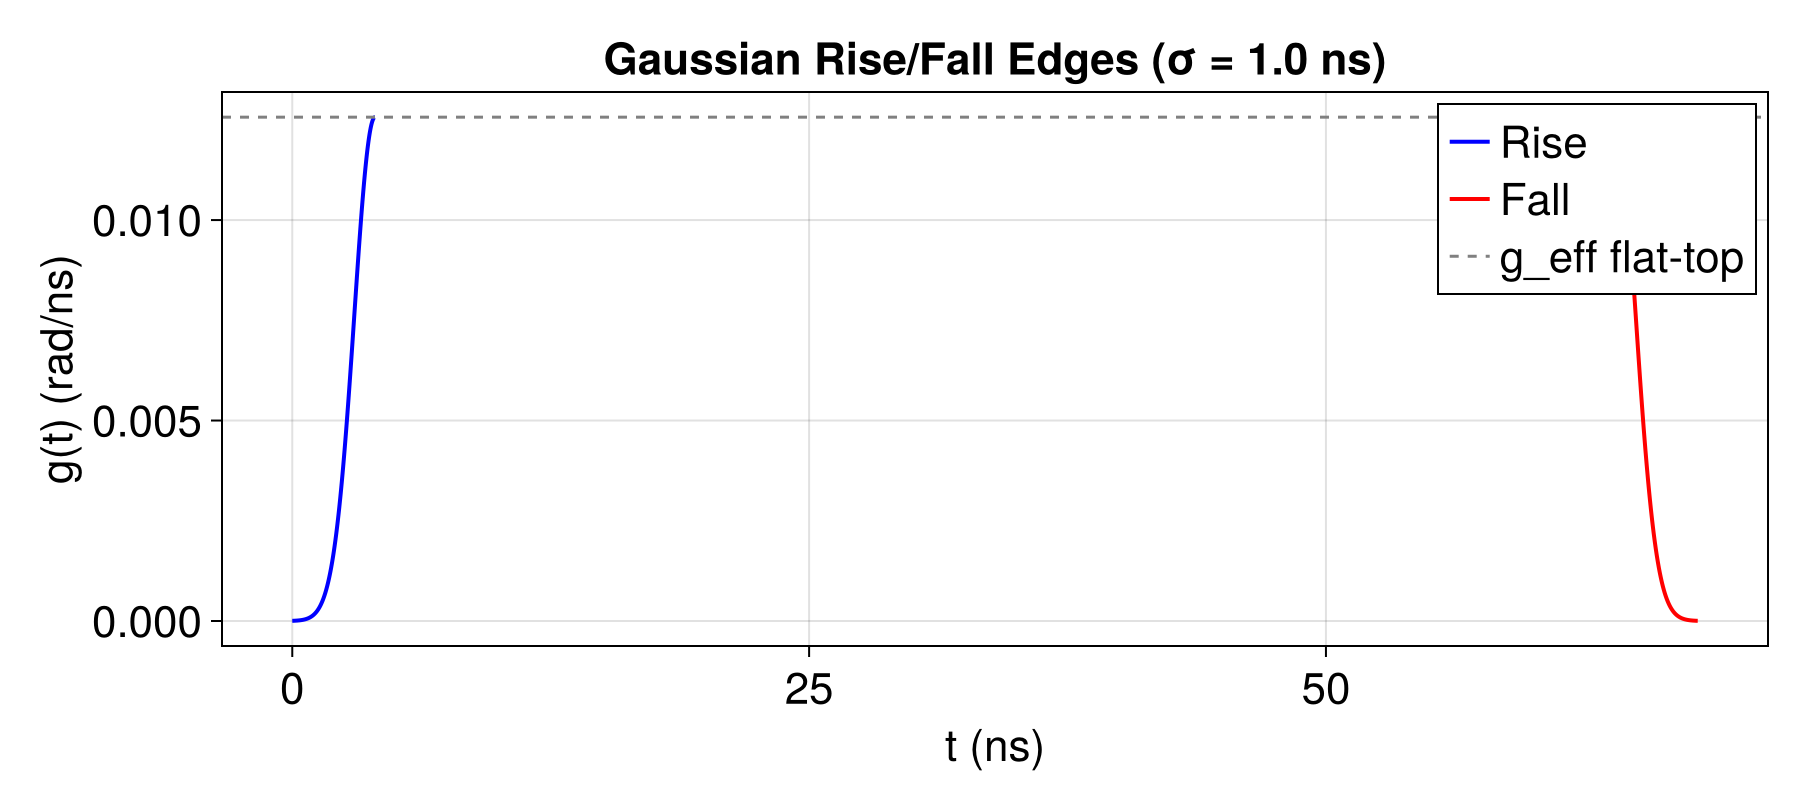

CairoMakie.Screen{IMAGE}


In [5]:
# Plot Gaussian edges
fig = Figure(fontsize=22, size=(900, 400))
ax = Axis(fig[1, 1], xlabel="t (ns)", ylabel="g(t) (rad/ns)",
    title="Gaussian Rise/Fall Edges (σ = $(σ_rise) ns)")
lines!(ax, t_rise, g_rise, label="Rise", linewidth=2, color=:blue)
lines!(ax, t_fall .+ buffer_duration .+ T_flat_est, g_fall, label="Fall", linewidth=2, color=:red)
hlines!(ax, [g_eff], linestyle=:dash, color=:gray, label="g_eff flat-top")
axislegend(ax)
display(fig)

## 4. Gate Frame Hamiltonian

Both qubits on-resonance at ω₁. Drives detuned by Δ_mw1, Δ_mw2.
The coupling is time-independent. The drive operators oscillate at the detuning.

In [6]:
# Gate-frame Hamiltonian for the flat-top region
# H(u, t) = g_eff(XX+YY) + modulated microwave drives
#
# 4 control channels: u = [u_X1, u_Y1, u_X2, u_Y2]
# g_eff is NOT a control — it's in the drift

function H_gate_frame(u, t)
    uX1, uY1, uX2, uY2 = u

    # Drift: constant coupling
    H = g_eff * (XX + YY)

    # Qubit 1 drives (detuned by Δ_mw1)
    c1 = cos(Δ_mw1 * t)
    s1 = sin(Δ_mw1 * t)
    H += uX1 * (XI * c1 + YI * s1)
    H += uY1 * (YI * c1 - XI * s1)

    # Qubit 2 drives (detuned by Δ_mw2)
    c2 = cos(Δ_mw2 * t)
    s2 = sin(Δ_mw2 * t)
    H += uX2 * (IX * c2 + IY * s2)
    H += uY2 * (IY * c2 - IX * s2)

    return H
end

# Variational error generators (time-independent)
H_vars = [
    (u, t) -> ZI,
    (u, t) -> IZ,
    (u, t) -> ZZ,
]

varsys = VariationalQuantumSystem(
    H_gate_frame, H_vars, 4, drive_bounds;
    time_dependent = true
)

println("levels = ", varsys.levels,
        "  n_drives = ", varsys.n_drives,
        "  n_vars = ", length(varsys.G_vars),
        "  time_dep = ", varsys.time_dependent)

levels = 4  n_drives = 4  n_vars = 3  time_dep = true


## 5. Robust Optimization (VariationalSplinePulseProblem)

In [7]:
T_f = T_total_ns   # total flat-top duration (set directly in cell 5)
Δt = T_f / N_knots

Random.seed!(42)
controls = 2 .* a_bound .* rand(4, n_samples) .- a_bound
times = collect(LinRange(0.0, T_f, n_samples))

du_init = zeros(4, n_samples)
pulse = CubicSplinePulse(controls, du_init, times)

qcp = VariationalSplinePulseProblem(
    varsys, pulse, U_goal, N_knots;
    Q                     = 0.0,
    Q_r                   = Q_r,
    R                     = 1e-3,
    du_bound              = Inf,
    Δt_bounds             = (Δt, Δt),
    dynamics_spline_order = 3,
    n_path_samples        = 3,
    piccolo_options       = PiccoloOptions(
        timesteps_all_equal = true,
        verbose             = true,
    ),
)

push!(qcp.prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_threshold, get_trajectory(qcp))
)

println("Trajectory components: ", keys(get_trajectory(qcp).components))
println("Initial Δt: ", Δt, " ns")
println("Δt bounds: ", (Δt, Δt), "  (locked at total T = $(N_knots*Δt) ns)")

    constructing VariationalSplinePulseProblem...
      pulse type: CubicSplinePulse{DataInterpolations.CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 3
      added augmented state :var_Ũ⃗  dim=128  (3 error channels)
      dynamics spline order: 3
      applying TimeStepsAllEqualConstraint
      added CubicHermitePathConstraint: 3 samples/interval, bound=±0.06283
Trajectory components: (:Ũ⃗, :Δt, :t, :u, :du, :var_Ũ⃗)
Initial Δt: 4.166666666666667 ns
Δt bounds: (4.166666666666667, 4.166666666666667)  (locked at total T = 100.0 ns)


In [8]:
# Initialize unitary trajectory with a consistent rollout
let
    traj    = get_trajectory(qcp)
    us      = traj[:u]
    dus     = traj[:du]              # cubic Hermite tangents (zero at this stage)
    ts      = vec(traj[:t])
    iso_dim = traj.dims[:Ũ⃗]

    nominal_sys = QuantumSystem(H_gate_frame, drive_bounds; time_dependent=true)
    nlp_pulse   = CubicSplinePulse(us, dus, ts)    # cubic Hermite to match NLP
    nlp_qtraj   = UnitaryTrajectory(nominal_sys, nlp_pulse, U_goal)

    Ũ⃗_init = hcat([operator_to_iso_vec(nlp_qtraj(t)) for t in ts]...)

    traj.data[traj.components[:Ũ⃗], :] .= Ũ⃗_init
    rows_var = traj.components[:var_Ũ⃗]
    traj.data[rows_var[1:iso_dim], :] .= Ũ⃗_init

    U_init = iso_vec_to_operator(Ũ⃗_init[:, end])
    F0 = abs2(tr(U_goal' * U_init)) / varsys.levels^2
    @printf("Initial fidelity (rollout init): %.6f\n", F0)
end

Initial fidelity (rollout init): 0.027606


In [9]:
solve!(qcp, max_iter=num_iter, print_level=5,
    options=IpoptOptions(eval_hessian=false,
        output_file="ipopt_robust_iswap_detuned_$(run_tag).log"))

    initializing optimizer...
      building evaluator: 2 integrators, 2 nonlinear constraints
      dynamics constraints: 3680, nonlinear constraints: 553
        integrator 1 jacobian structure: 0.132s
        integrator 2 jacobian structure: 0.041s
        constraint 1 (CubicHermitePathConstraint) jacobian structure: 0.524s
        constraint 2 (NonlinearKnotPointConstraint) jacobian structure: 0.56s
      jacobian structure: 1257124 nonzeros (1.282s)
        integrator 1 hessian structure: 0.305s
        integrator 2 hessian structure: 0.083s
        constraint 1 (CubicHermitePathConstraint) hessian structure: 1.637s
        constraint 2 (NonlinearKnotPointConstraint) hessian structure: 3.585s
        computing objective hessian structure (CompositeObjective)...
          sub-objective 1 (KnotPointObjective): 0.124s
          sub-objective 2 (QuadraticRegularizer): 0.119s
          sub-objective 3 (QuadraticRegularizer): 0.0s
          sub-objective 4 (KnotPointObjective): 0.0s
   

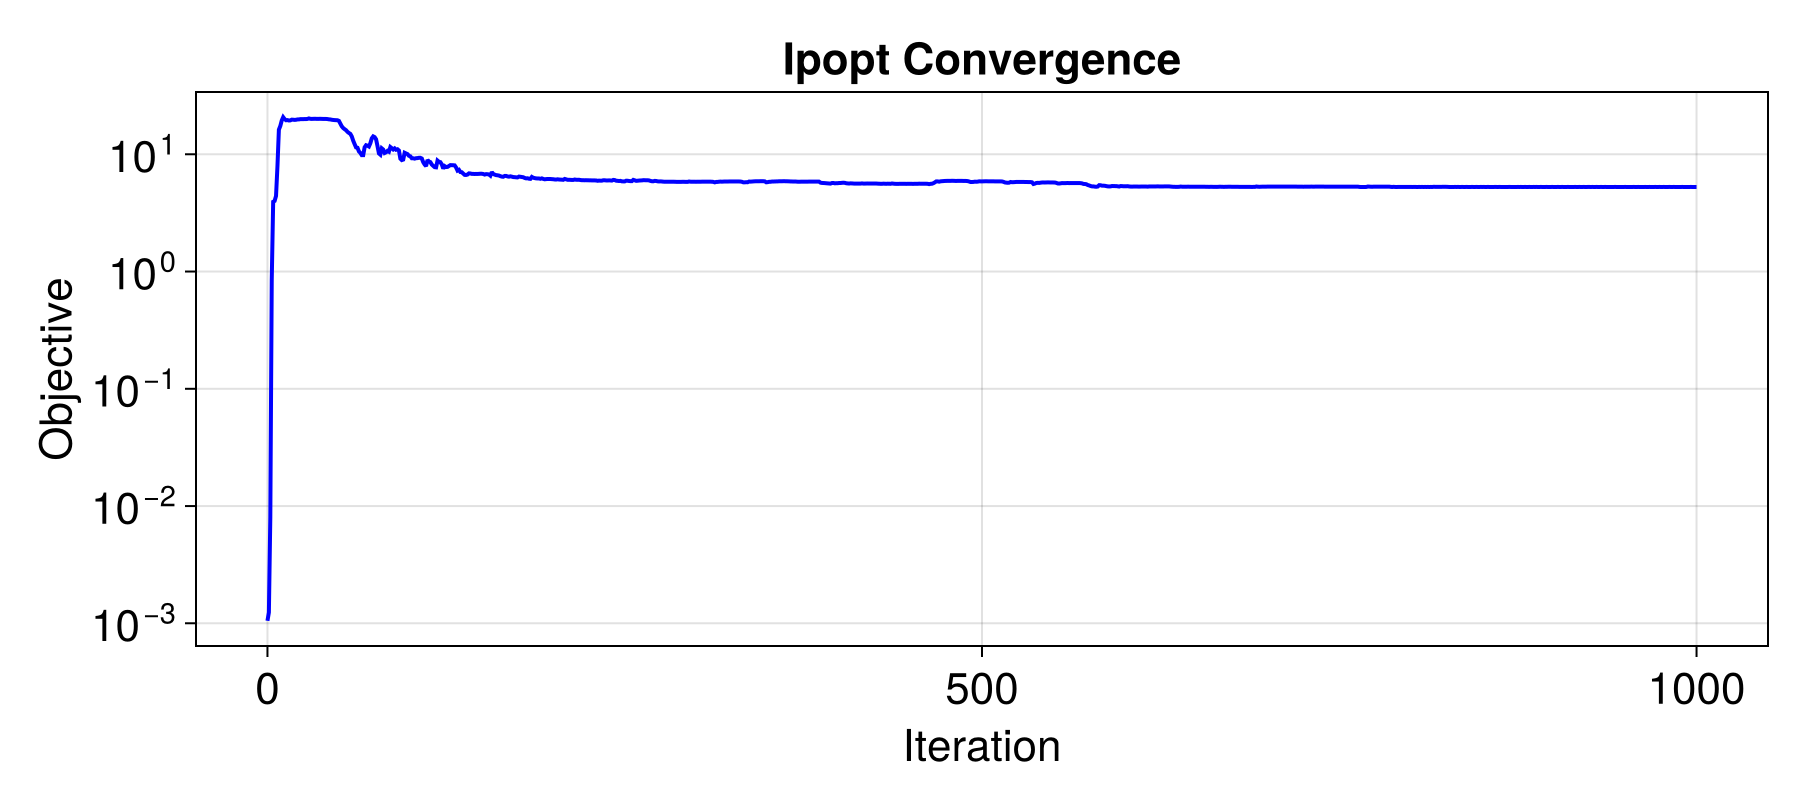

Final objective: 5.2617021 at iteration 1000


In [10]:
# Parse Ipopt log and plot objective vs iteration
log_path = "ipopt_robust_iswap_detuned_$(run_tag).log"
lines_log = readlines(log_path)

iters = Int[]
objs = Float64[]

for line in lines_log
    m = match(r"^\s*(\d+)\s+([\d.e+\-]+)\s+", line)
    if m !== nothing
        push!(iters, parse(Int, m.captures[1]))
        push!(objs, parse(Float64, m.captures[2]))
    end
end

fig = Figure(fontsize=22, size=(900, 400))
ax = Axis(fig[1, 1], xlabel="Iteration", ylabel="Objective",
    title="Ipopt Convergence", yscale=log10)
lines!(ax, iters, objs; linewidth=2, color=:blue)
display(fig)
println("Final objective: ", objs[end], " at iteration ", iters[end])

## 6. Results

In [11]:
traj = get_trajectory(qcp)
U_flat = iso_vec_to_operator(traj[:Ũ⃗][:, end])
F_flat = abs2(tr(U_goal' * U_flat)) / varsys.levels^2
@printf("Flat-top fidelity to U_goal: %.8f\n", F_flat)
@printf("Flat-top infidelity: %.2e\n", 1 - F_flat)

# Full gate verification
U_full = V_fall * U_flat * V_rise
F_full = abs2(tr(U_iswap' * U_full)) / 4^2
@printf("Full gate fidelity to iSWAP: %.8f\n", F_full)
@printf("Full gate infidelity: %.2e\n", 1 - F_full)

# Optimized Δt
println("Optimized Δt: ", traj[:t][2] - traj[:t][1], " ns")
println("Optimized T_flat: ", traj[:t][end], " ns")

# Total gate time
T_total = buffer_duration + traj[:t][end] + buffer_duration
println("Total gate time (rise + flat + fall): ", round(T_total, digits=2), " ns")

# Virtual Z correction
φ_vz = δ₁₂ * T_total
println("Virtual Z on q2: Rz(", round(φ_vz, digits=4), " rad) = Rz(",
    round(φ_vz/(2π), digits=4), " × 2π)")

Flat-top fidelity to U_goal: 0.99990011
Flat-top infidelity: 9.99e-05
Full gate fidelity to iSWAP: 0.99990011
Full gate infidelity: 9.99e-05
Optimized Δt: 4.166666666666667 ns
Optimized T_flat: 95.83333333333334 ns
Total gate time (rise + flat + fall): 103.83 ns
Virtual Z on q2: Rz(39.1442 rad) = Rz(6.23 × 2π)


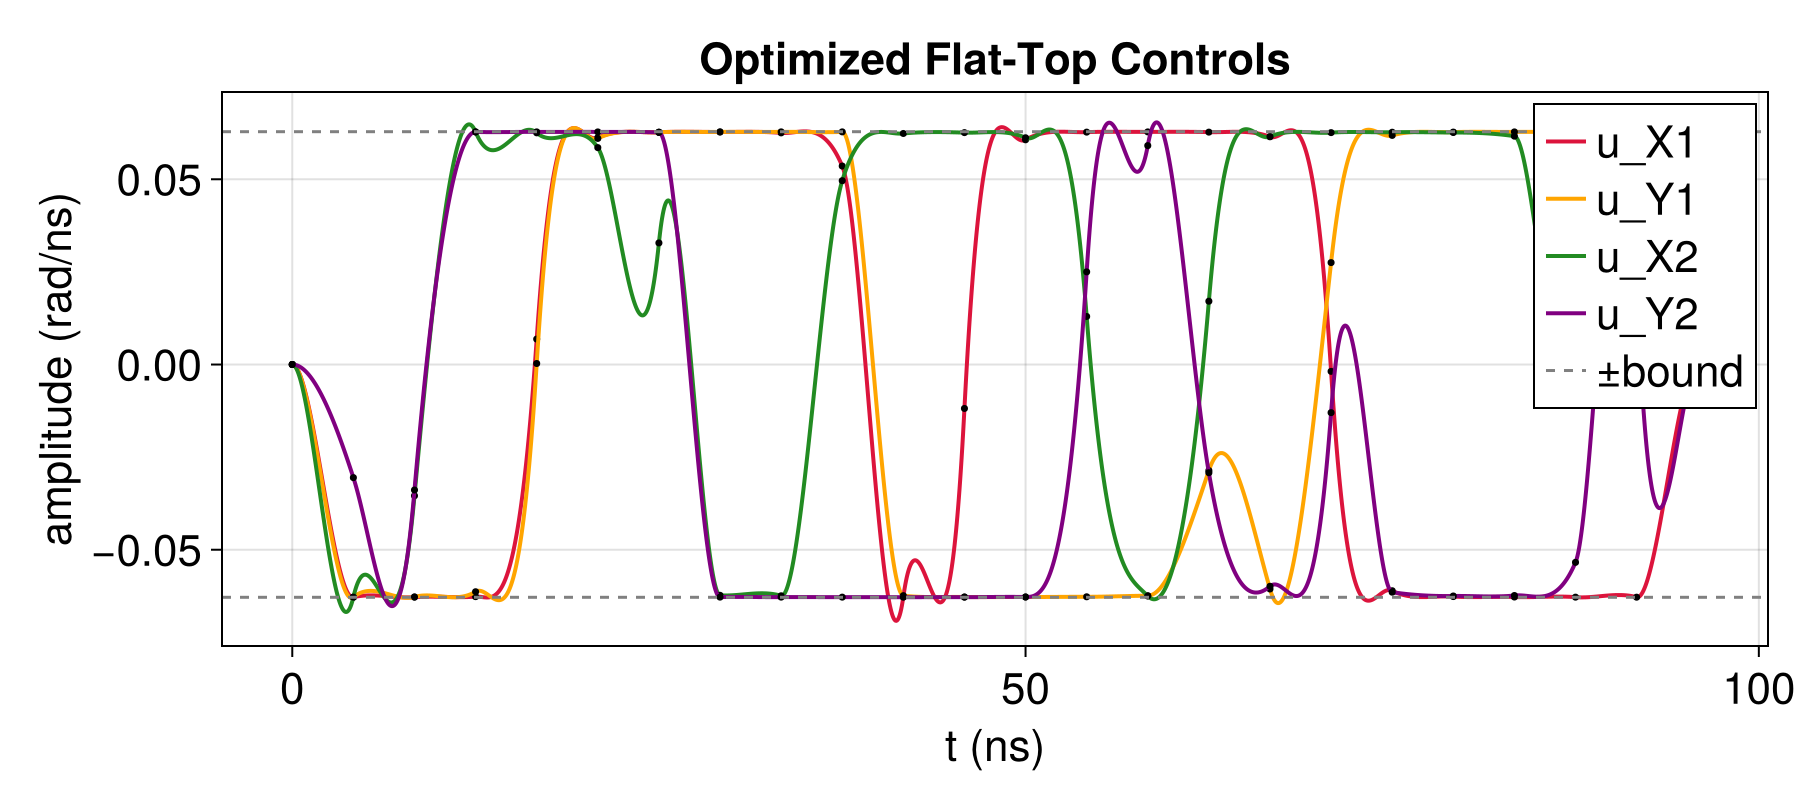

CairoMakie.Screen{IMAGE}


In [12]:
# Plot optimized controls
function _spline_fine(traj)
    ts_knots = vec(traj[:t])
    us_knots = traj[:u]
    du_knots = traj[:du]
    pulse    = CubicSplinePulse(us_knots, du_knots, ts_knots)
    ts_fine  = collect(LinRange(ts_knots[1], ts_knots[end], 2000))
    us_fine  = sample(pulse, ts_fine)
    return ts_knots, us_knots, ts_fine, us_fine
end

ts_knots, us_knots, ts_fine, us_fine = _spline_fine(traj)

labels = ["u_X1", "u_Y1", "u_X2", "u_Y2"]
colors_ctrl = [:crimson, :orange, :forestgreen, :purple]

fig = Figure(size=(900, 400), fontsize=22)
ax = Axis(fig[1, 1], xlabel="t (ns)", ylabel="amplitude (rad/ns)",
    title="Optimized Flat-Top Controls")

for (i, (lbl, col)) in enumerate(zip(labels, colors_ctrl))
    lines!(ax, ts_fine, vec(us_fine[i, :]); label=lbl, color=col, linewidth=2)
    scatter!(ax, ts_knots, vec(us_knots[i, :]); color=:black, markersize=5)
end
hlines!(ax, [a_bound, -a_bound]; linestyle=:dash, color=:gray, label="±bound")
axislegend(ax, position=:rt)
display(fig)

## 6b. Default Baseline: Gaussian Square (no microwaves)

The default iSWAP is a Gaussian square pulse on g_eff only — same edge shape
(σ_rise), but with a flat-top duration chosen so the total area ∫g(t)dt = π/4.
No microwave drives. This is what experiment would do without robust control.

In [13]:
# --- Build Gaussian square pulse (coupling only, no microwaves) ---
# Same σ_rise edges, find flat-top width so total area = π/4

function gaussian_square_area(flat_ns; g_eff=g_eff, σ=σ_rise, dt=0.01, trunc=4)
    buf = trunc * σ
    # Rise: g_eff * exp(-(t - buf)² / (2σ²)) for t ∈ [0, buf]
    t_rise = collect(0:dt:buf)
    g_rise_seg = g_eff .* exp.(-(t_rise .- buf).^2 ./ (2σ^2))
    A_rise = sum(g_rise_seg) * dt

    # Flat-top
    A_flat = g_eff * flat_ns

    # Fall: same as rise by symmetry
    A_fall = A_rise

    return A_rise + A_flat + A_fall
end

# Bisect to find flat-top width giving total area = π/4
let target = π/4, lo = 0.0, hi = 400.0
    for _ in 1:100
        mid = (lo + hi) / 2
        gaussian_square_area(mid) < target ? (lo = mid) : (hi = mid)
    end
    global flat_default = (lo + hi) / 2
end

println("Default Gaussian square flat-top width: ", round(flat_default, digits=4), " ns")
println("Total area check: ", round(gaussian_square_area(flat_default), digits=8),
        " (π/4 = ", round(π/4, digits=8), ")")

# --- Build the full default pulse on a fine time grid ---
buf = 4 * σ_rise
dt_default = 0.01
T_default = buf + flat_default + buf

t_default = collect(0:dt_default:T_default)
g_default = zeros(length(t_default))

for (i, t) in enumerate(t_default)
    if t < buf
        # Rising edge
        g_default[i] = g_eff * exp(-(t - buf)^2 / (2σ_rise^2))
    elseif t < buf + flat_default
        # Flat-top
        g_default[i] = g_eff
    else
        # Falling edge
        t_fall = t - buf - flat_default
        g_default[i] = g_eff * exp(-t_fall^2 / (2σ_rise^2))
    end
end

println("Default total gate time: ", round(T_default, digits=2), " ns")
println("Default total area: ", round(sum(g_default)*dt_default, digits=8))

Default Gaussian square flat-top width: 59.9835 ns
Total area check: 0.78539816 (π/4 = 0.78539816)
Default total gate time: 67.98 ns
Default total area: 0.78527248


## 7. Robustness Verification: Default vs Robust


In [14]:
# --- Robustness sweep setup ---
εs         = collect(range(-0.02, 0.02, length=101))
errors     = [(ZI, "ZI"), (IZ, "IZ"), (ZZ, "ZZ")]
err_colors = [:red, :blue, :green]

F_vs_eps         = Dict{String, Vector{Float64}}()
F_default_vs_eps = Dict{String, Vector{Float64}}()

outdir = "robust_iswap_detuned_$(run_tag)"
mkpath(joinpath(outdir, "figs"))                                                                                                                                       

"robust_iswap_detuned_2MHz_100ns/figs"

In [15]:
T_flat_est * 4

239.93410867666782

In [16]:
# --- Simulate full robust gate (V_rise + flat-top + V_fall) WITH error ---                                                                                                                             
function simulate_edge_unitary(g_pulse, t_pulse, dt, ε_op, ε_val)                                                                                                                                       
    N = length(g_pulse)                                                                                                                                                                                 
    T_ns = t_pulse[end]                                                                                                                                                                                 
                                                                                                                                                                                                        
    function H_edge_err(u, t)
        idx = clamp(round(Int, t / dt) + 1, 1, N)                                                                                                                                                       
        return g_pulse[idx] * (XX + YY) + ε_val * ε_op
    end                                                                                                                                                                                                 
 
    edge_sys = QuantumSystem(H_edge_err, Float64[]; time_dependent=true)                                                                                                                                
    ts_prop = collect(LinRange(0.0, T_ns, min(N, 2000)))
    dummy_pulse = LinearSplinePulse(zeros(0, length(ts_prop)), ts_prop)                                                                                                                                 
    qtraj = UnitaryTrajectory(edge_sys, dummy_pulse, Matrix{ComplexF64}(I, 4, 4))                                                                                                                       
    return qtraj(T_ns)                                                                                                                                                                                  
end                                                                                                                                                                                                     
                
# --- Build edge pulses on fine grids ---                                                                                                                                                               
dt_edge = 0.01  
buf = 4 * σ_rise

t_rise_fine = collect(0:dt_edge:buf)                                                                                                                                                                    
g_rise_fine = g_eff .* exp.(-(t_rise_fine .- buf).^2 ./ (2 * σ_rise^2))
                                                                                                                                                                                                        
t_fall_fine = collect(0:dt_edge:buf)
g_fall_fine = g_eff .* exp.(-(t_fall_fine).^2 ./ (2 * σ_rise^2))                                                                                                                                        
                                                                                                                                                                                                        
function simulate_full_gate_fidelity(traj, ε_op, ε_val)
    V_rise_err = simulate_edge_unitary(g_rise_fine, t_rise_fine, dt_edge, ε_op, ε_val)                                                                                                                  
    V_fall_err = simulate_edge_unitary(g_fall_fine, t_fall_fine, dt_edge, ε_op, ε_val)                                                                                                                  
                                                                                                                                                                                                        
    ts  = vec(traj[:t])                                                                                                                                                                                 
    us  = traj[:u]                                                                                                                                                                                      
    dus = traj[:du]

    function H_with_error(u, t)                                                                                                                                                                         
        return H_gate_frame(u, t) + ε_val * ε_op
    end                                                                                                                                                                                                 
                
    err_sys    = QuantumSystem(H_with_error, drive_bounds; time_dependent=true)                                                                                                                         
    nlp_pulse  = CubicSplinePulse(us, dus, ts)
    qtraj      = UnitaryTrajectory(err_sys, nlp_pulse, U_goal)                                                                                                                                          
    U_flat_err = qtraj(ts[end])                                                                                                                                                                         
 
    U_full_err = V_fall_err * U_flat_err * V_rise_err                                                                                                                                                   
    return abs2(tr(U_iswap' * U_full_err)) / 4^2
end                                                                                                                                                                                                     
 
for (err_op, err_name) in errors                                                                                                                                                                        
    F_curve = Float64[]
    for ε in εs
        push!(F_curve, simulate_full_gate_fidelity(traj, err_op, ε))
    end                                                                                                                                                                                                 
    F_vs_eps[err_name] = F_curve
    println("Robust $err_name sweep complete")                                                                                                                                                          
end                      

Robust ZI sweep complete
Robust IZ sweep complete
Robust ZZ sweep complete


In [17]:
 # --- Simulate default Gaussian-square pulse with errors everywhere ---                                                                                                                                 
 function simulate_default_fidelity(g_pulse, t_pulse, dt, ε_op, ε_val)                                                                                                                                   
    N = length(g_pulse)
    T_ns = t_pulse[end]                                                                                                                                                                                 
                                                                                                                                                                                                        
    function H_default(u, t)
        idx = clamp(round(Int, t / dt) + 1, 1, N)                                                                                                                                                       
        return g_pulse[idx] * (XX + YY) + ε_val * ε_op
    end                                                                                                                                                                                                 
 
    def_sys = QuantumSystem(H_default, Float64[]; time_dependent=true)                                                                                                                                  
    ts_prop = collect(LinRange(0.0, T_ns, min(N, 2000)))
    dummy_pulse = LinearSplinePulse(zeros(0, length(ts_prop)), ts_prop)                                                                                                                                 
    qtraj = UnitaryTrajectory(def_sys, dummy_pulse, U_iswap)                                                                                                                                            
    U_def = qtraj(T_ns)                                                                                                                                                                                 
    return abs2(tr(U_iswap' * U_def)) / 4^2                                                                                                                                                             
end                                                                                                                                                                                                     
 
for (err_op, err_name) in errors                                                                                                                                                                        
    F_curve = Float64[]
    for ε in εs
        push!(F_curve, simulate_default_fidelity(g_default, t_default, dt_default, err_op, ε))
    end                                                                                                                                                                                                 
    F_default_vs_eps[err_name] = F_curve
    println("Default $err_name sweep complete")                                                                                                                                                         
end                      

Default ZI sweep complete
Default IZ sweep complete
Default ZZ sweep complete


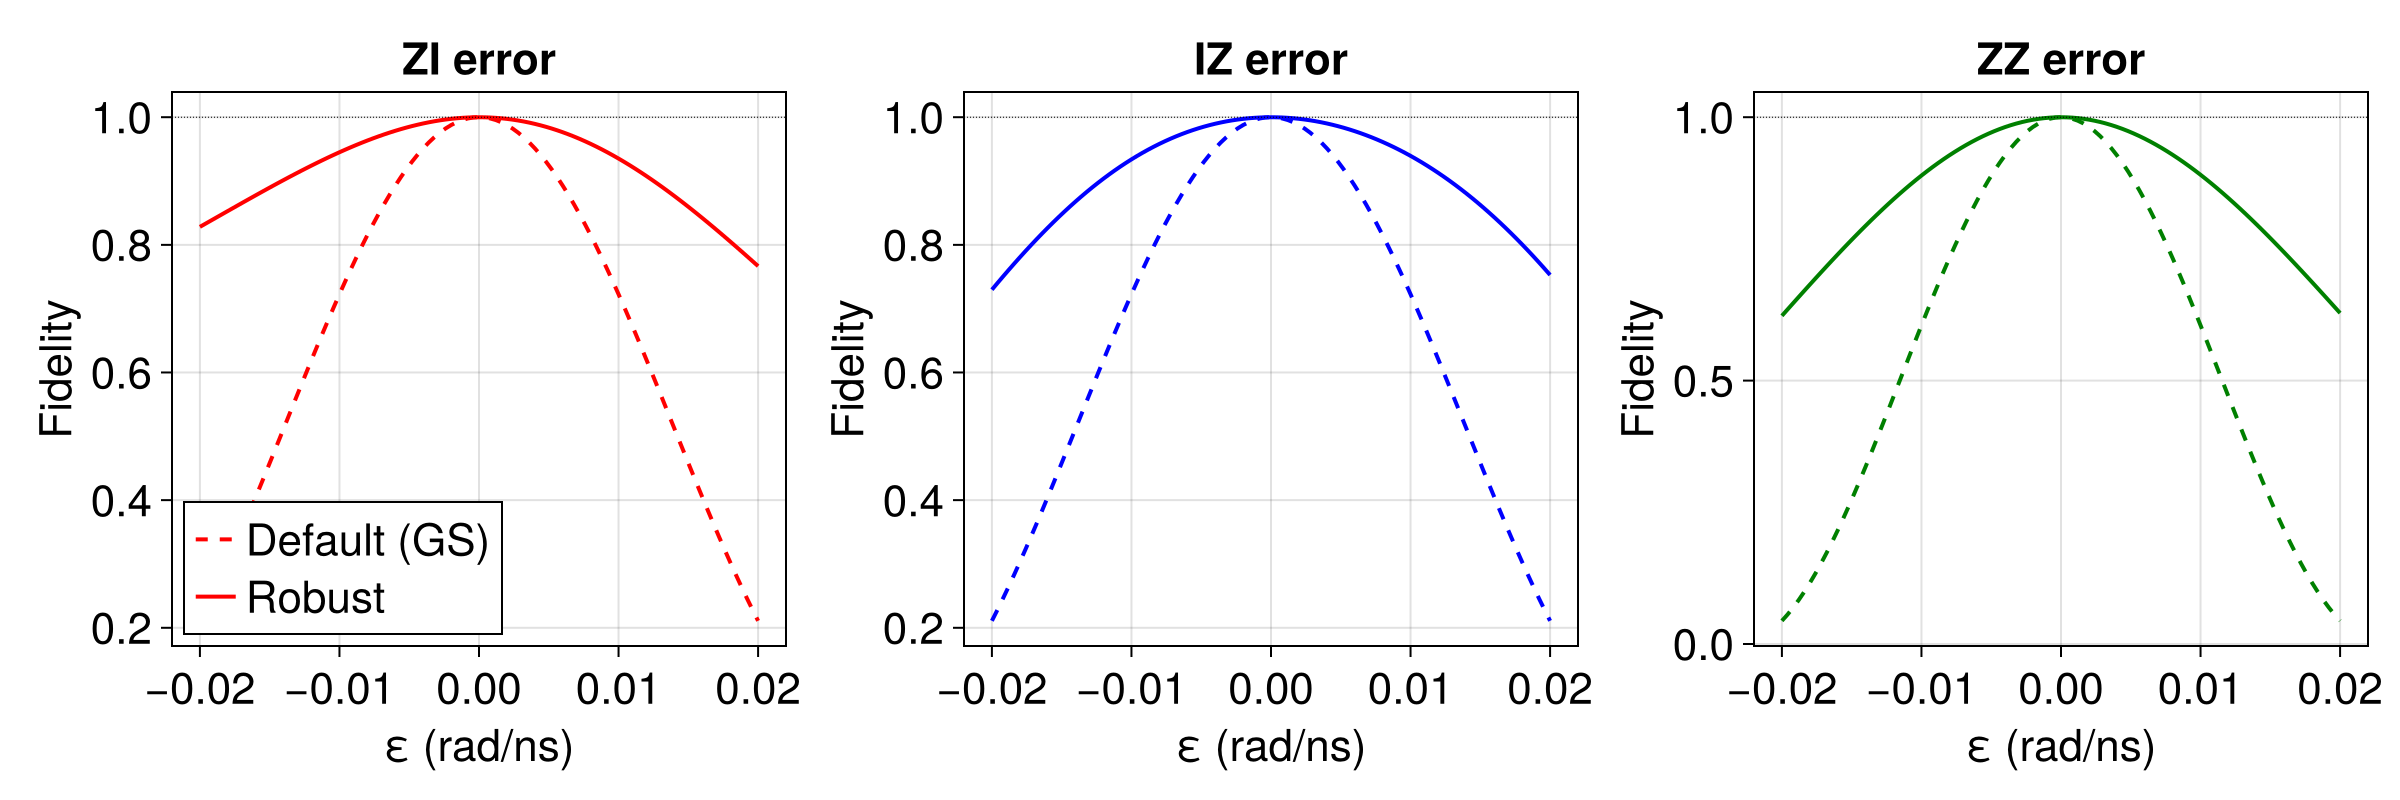

In [18]:
# Plot fidelity comparison: default vs robust (linear)
fig = Figure(fontsize=22, size=(1200, 400))

for (col, ((err_op, err_name), ecol)) in enumerate(zip(errors, err_colors))
    ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="Fidelity",
        title="$err_name error")
    lines!(ax, εs, F_default_vs_eps[err_name];
        color=ecol, linewidth=2, linestyle=:dash, label="Default (GS)")
    lines!(ax, εs, F_vs_eps[err_name];
        color=ecol, linewidth=2, label="Robust")
    hlines!(ax, [F_threshold]; linestyle=:dot, color=:black, linewidth=0.5)
    if col == 1; axislegend(ax, position=:lb); end
end

display(fig)
save(joinpath(outdir, "figs", "default_vs_robust.png"), fig)


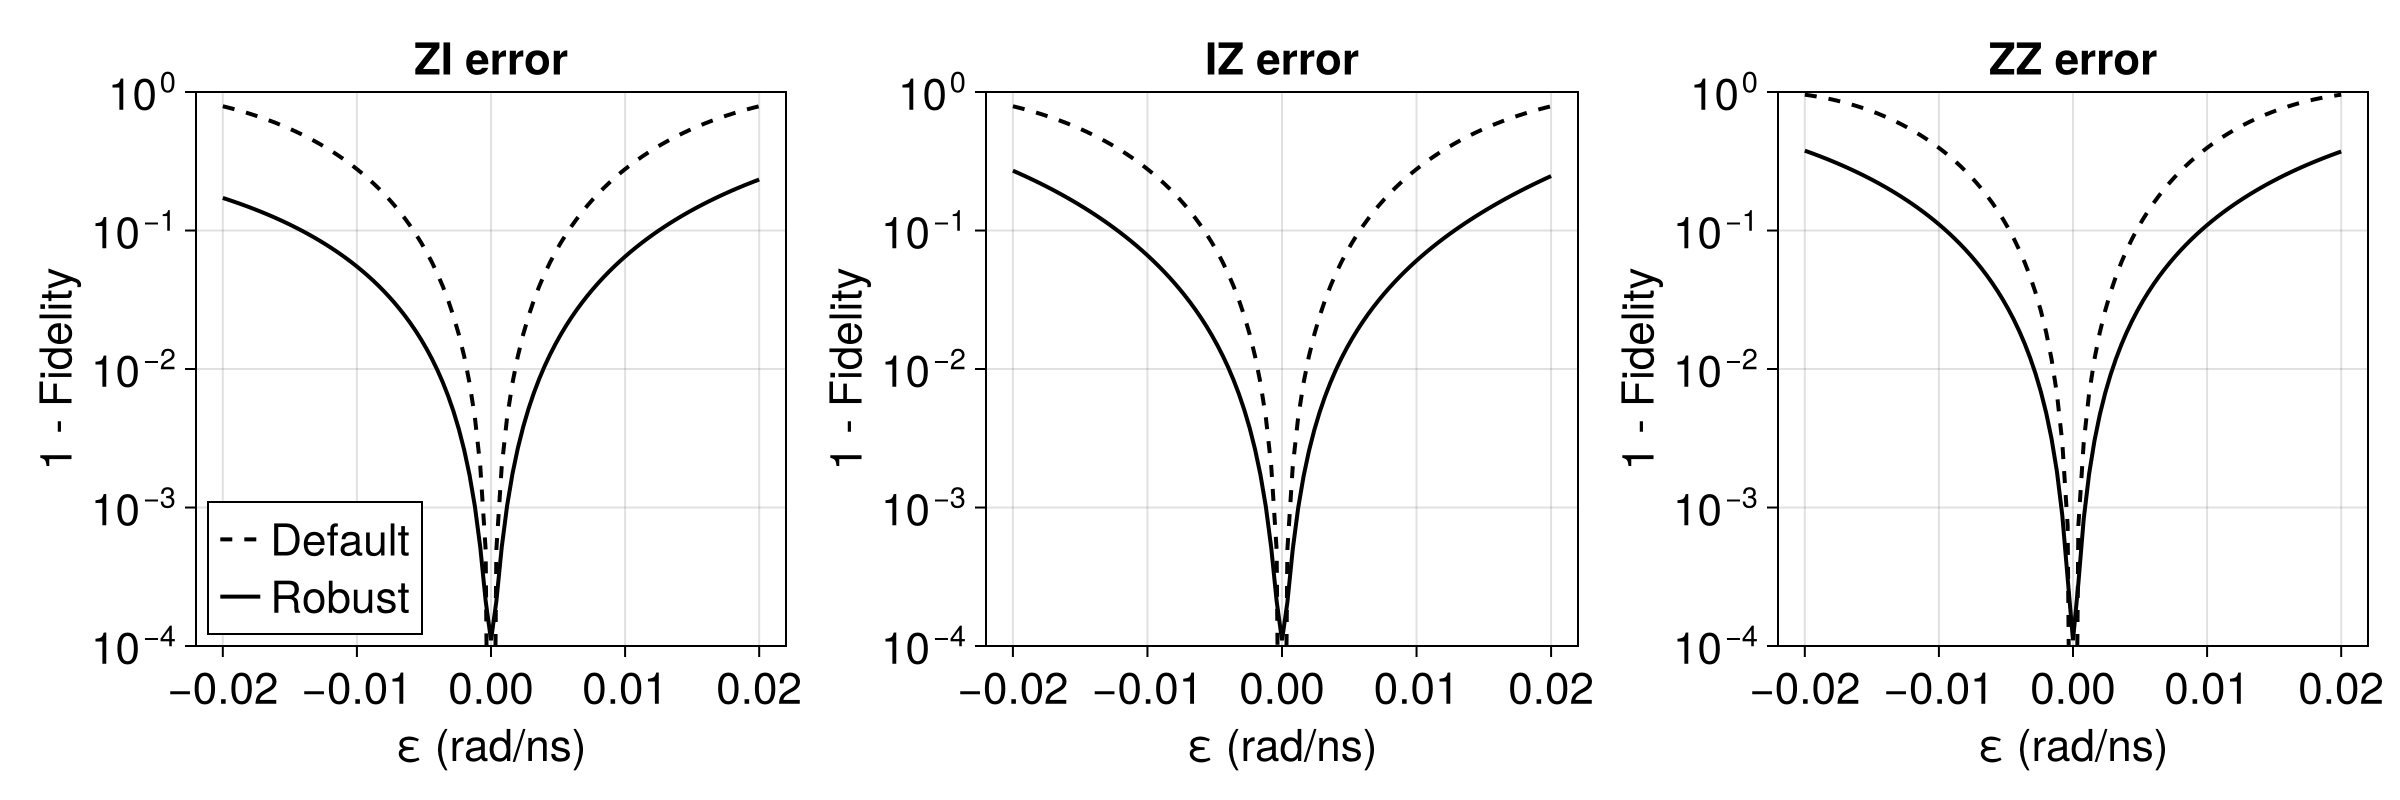

In [38]:
  # Plot infidelity comparison: default vs robust (log scale)
  fig = Figure(fontsize=22, size=(1200, 400))                                                                                                                                                             
   
  for (col, ((err_op, err_name), ecol)) in enumerate(zip(errors, err_colors))                                                                                                                             
      ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="1 - Fidelity",
          title="$err_name error", yscale=log10)                                                                                                                                                          
      lines!(ax, εs, max.(1 .- F_default_vs_eps[err_name], 1e-16);
          color=:black, linewidth=2, linestyle=:dash, label="Default")                                                                                                                                    
      lines!(ax, εs, max.(1 .- F_vs_eps[err_name], 1e-16);                                                                                                                                                
          color=:black, linewidth=2, label="Robust")
      ylims!(ax, 1e-4, 1.0)                                                                                                                                                                               
      if col == 1; axislegend(ax, position=:lb); end
  end                                                                                                                                                                                                     
                  
  display(fig)                                                                                                                                                                                            
  save(joinpath(outdir, "figs", "default_vs_robust_log.png"), fig)

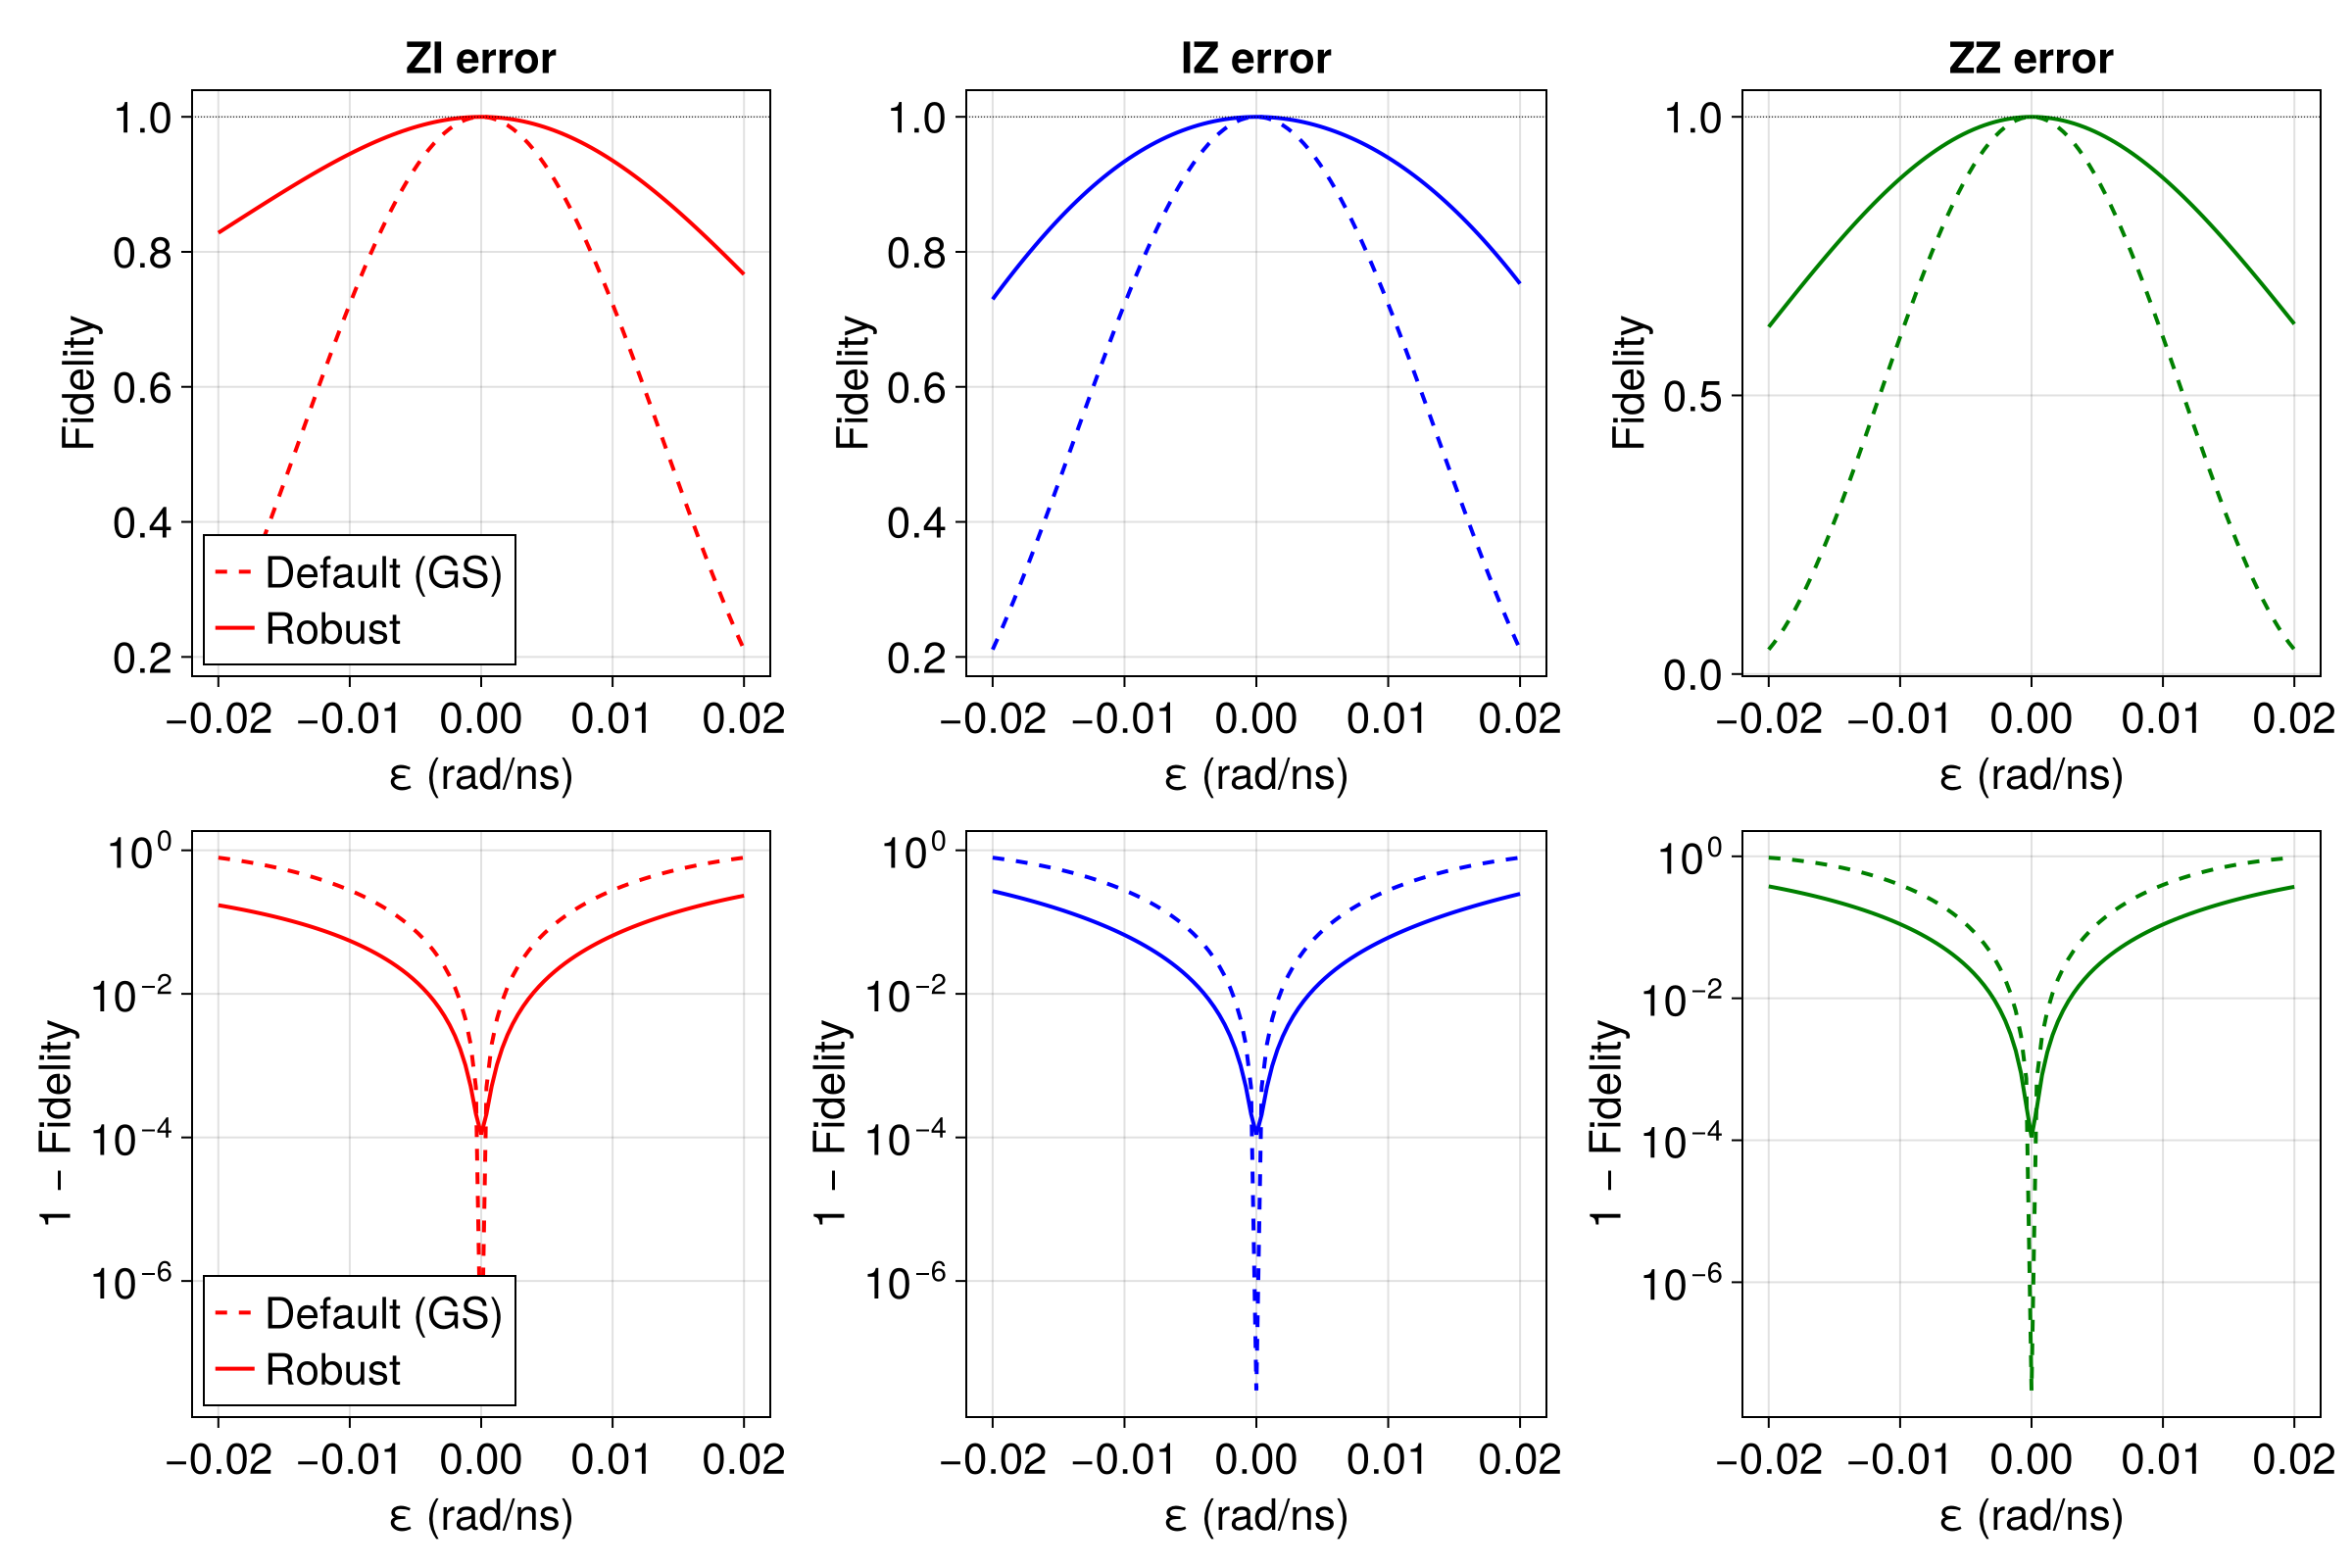

In [25]:
# Plot fidelity comparison: default vs robust (linear top, log infidelity bottom)                                               
fig = Figure(fontsize=22, size=(1200, 800))                                                                                     
                                                                                                                                                                                                          
for (col, ((err_op, err_name), ecol)) in enumerate(zip(errors, err_colors))                                                                                                                             
    # Top row — linear fidelity                                                                                                                                                                         
    ax_lin = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="Fidelity",                                                                                                                                  
        title="$err_name error")                                                                                                                                                                        
    lines!(ax_lin, εs, F_default_vs_eps[err_name];
        color=ecol, linewidth=2, linestyle=:dash, label="Default (GS)")                                                                                                                                 
    lines!(ax_lin, εs, F_vs_eps[err_name];
        color=ecol, linewidth=2, label="Robust")                                                                                                                                                        
    hlines!(ax_lin, [F_threshold]; linestyle=:dot, color=:black, linewidth=0.5)
    if col == 1; axislegend(ax_lin, position=:lb); end                                                                                                                                                  
                
    # Bottom row — log infidelity                                                                                                                                                                       
    ax_log = Axis(fig[2, col], xlabel="ε (rad/ns)", ylabel="1 − Fidelity",
        yscale=log10)                                                                                                                                                                                   
    lines!(ax_log, εs, max.(1 .- F_default_vs_eps[err_name], 1e-16);
        color=ecol, linewidth=2, linestyle=:dash, label="Default (GS)")                                                                                                                                 
    lines!(ax_log, εs, max.(1 .- F_vs_eps[err_name], 1e-16);
        color=ecol, linewidth=2, label="Robust")                                                                                                                                                        
    if col == 1; axislegend(ax_log, position=:lb); end
end                                                                                                                                                                                                     
                                                                                                                                                                                                        
# Link x-axes column-wise so panning matches across rows                                                                                                                                                
for col in 1:length(errors)                                                                                                                                                                             
    linkxaxes!(contents(fig[1, col])[1], contents(fig[2, col])[1])                                                                                                                                      
end

display(fig)                                                                                                                                                                                            
save(joinpath(outdir, "figs", "default_vs_robust_6panel.png"), fig)

## 8. Save Results

In [20]:
using DelimitedFiles                                                                                                            
                                                                                                                                                                                                                                                                                               
                                                                                                                                                                                                        
  # Save controls (transposed — rows = time, columns = channels)                                                                                                                                      
  ts_knots_save, us_knots_save, ts_fine_save, us_fine_save = _spline_fine(traj)                                                                                                                         
                                                                                                                                                                                                        
  open(joinpath(outdir, "controls_fine.csv"), "w") do io
      println(io, "time_ns,u_X1,u_Y1,u_X2,u_Y2")                                                                                                                                                        
      for j in 1:length(ts_fine_save)                                                                                                                                                                   
          println(io, "$(ts_fine_save[j]),$(us_fine_save[1,j]),$(us_fine_save[2,j]),$(us_fine_save[3,j]),$(us_fine_save[4,j])")
      end                                                                                                                                                                                               
  end                                                                                                                                                                                                   
                                                                                                                                                                                                        
  # Save fidelity curves                                                                                                                                                                                
  for (err_op, err_name) in errors
      open(joinpath(outdir, "fidelity_$(err_name).csv"), "w") do io
          println(io, "epsilon,fidelity")
          for (ε, F_val) in zip(εs, F_vs_eps[err_name])
              println(io, "$ε,$F_val")                                                                                                                                                                  
          end
      end                                                                                                                                                                                               
  end             

  # Save parameters
  open(joinpath(outdir, "parameters.txt"), "w") do io
      println(io, "g_eff = $g_eff rad/ns ($(round(g_eff/(2π)*1e3, digits=1)) MHz)")                                                                                                                     
      println(io, "δ₁₂ = $δ₁₂ rad/ns ($(round(δ₁₂/(2π)*1e3, digits=1)) MHz)")
      println(io, "Δ_mw1 = $Δ_mw1 rad/ns ($(round(Δ_mw1/(2π)*1e3, digits=1)) MHz)")                                                                                                                     
      println(io, "Δ_mw2 = $Δ_mw2 rad/ns ($(round(Δ_mw2/(2π)*1e3, digits=1)) MHz)")                                                                                                                     
      println(io, "a_bound = $a_bound rad/ns ($(round(a_bound/(2π)*1e3, digits=1)) MHz)")                                                                                                               
      println(io, "σ_rise = $σ_rise ns")                                                                                                                                                                
      println(io, "buffer_duration = $buffer_duration ns")                                                                                                                                              
      println(io, "A_rise = $A_rise rad")
      println(io, "A_fall = $A_fall rad")                                                                                                                                                               
      println(io, "θ_goal = $θ_goal rad")                                                                                                                                                             
      println(io, "T_flat = $(traj[:t][end]) ns")                                                                                                                                                       
      println(io, "T_total = $T_total ns")
      println(io, "F_threshold = $F_threshold")                                                                                                                                                         
      println(io, "Virtual Z on q2 = $(φ_vz) rad")                                                                                                                                                      
  end
                                                                                                                                                                                                        
  println("Saved to: ", abspath(outdir))

Saved to: /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/robust_iswap_detuned_2MHz_100ns


In [29]:
# Full pulse: Gaussian rise + flat-top (g_eff + microwaves) + Gaussian fall                                                     
ts_knots, us_knots, ts_fine_mw, us_fine_mw = _spline_fine(traj)                                                                 
T_flat_opt = ts_fine_mw[end]                                                                                                                                                                            
                                                                                                                                                                                                        
# Build time axis for full pulse                                                                                                                                                                        
dt_plot = 0.05                                                                                                                                                                                          
t_rise_plot = collect(0:dt_plot:buffer_duration)                                                                                                                                                        
t_flat_plot = collect(0:dt_plot:T_flat_opt) .+ buffer_duration
t_fall_plot = collect(0:dt_plot:buffer_duration) .+ buffer_duration .+ T_flat_opt                                                                                                                       
                
# g_eff envelope                                                                                                                                                                                        
g_rise_plot = g_eff .* exp.(-(t_rise_plot .- buffer_duration).^2 ./ (2σ_rise^2))
g_flat_plot = fill(g_eff, length(t_flat_plot))                                                                                                                                                          
g_fall_plot = g_eff .* exp.(-(t_fall_plot .- buffer_duration .- T_flat_opt).^2 ./ (2σ_rise^2))                                                                                                          
                                                                                                                                                                                                        
fig = Figure(size=(1000, 500), fontsize=22)                                                                                                                                                             
                                                                                                                                                                                                        
# Top panel: g_eff envelope
ax1 = Axis(fig[1, 1], ylabel="g_eff (rad/ns)",
    title="Full Pulse: Gaussian Square + Optimized Microwaves")                                                                                                                                         
lines!(ax1, t_rise_plot, g_rise_plot; color=:black, linewidth=2)
lines!(ax1, t_flat_plot, g_flat_plot; color=:black, linewidth=2, label="g_eff")                                                                                                                         
lines!(ax1, t_fall_plot, g_fall_plot; color=:black, linewidth=2)
vspan!(ax1, [0], [buffer_duration]; color=(:gray, 0.1))                                                                                                                                                 
vspan!(ax1, [buffer_duration + T_flat_opt], [buffer_duration + T_flat_opt + buffer_duration]; color=(:gray, 0.1))                                                                                       
                                                                                                                                                                                                        
# Bottom panel: microwave controls (shifted to flat-top region)                                                                                                                                         
ax2 = Axis(fig[2, 1], xlabel="t (ns)", ylabel="amplitude (rad/ns)")                                                                                                                                     
labels = ["u_X1", "u_Y1", "u_X2", "u_Y2"]                                                                                                                                                               
colors_ctrl = [:crimson, :orange, :forestgreen, :purple]
                                                                                                                                                                                                        
for (i, (lbl, col)) in enumerate(zip(labels, colors_ctrl))
    lines!(ax2, ts_fine_mw .+ buffer_duration, vec(us_fine_mw[i, :]);                                                                                                                                   
        label=lbl, color=col, linewidth=2)                                                                                                                                                              
    scatter!(ax2, ts_knots .+ buffer_duration, vec(us_knots[i, :]);
        color=:black, markersize=6,                                                                                                                                                                     
        label = i == 1 ? "knots" : nothing)
end                                                                                                                                                                                                     
hlines!(ax2, [a_bound, -a_bound]; linestyle=:dash, color=:gray, label="±bound")
vspan!(ax2, [0], [buffer_duration]; color=(:gray, 0.1), label="buffer")                                                                                                                                 
vspan!(ax2, [buffer_duration + T_flat_opt], [buffer_duration + T_flat_opt + buffer_duration]; color=(:gray, 0.1))                                                                                       
                                                                                                                                                                                                        
# Single combined legend, overlaid at the bottom of the top panel                                                                                                                                       
Legend(fig[1, 1], [ax1, ax2];                                                                                                                                                                           
    halign         = :center,                                                                                                                                                                           
    valign         = :bottom,
    tellwidth      = false,                                                                                                                                                                             
    tellheight     = false,
    framevisible   = true,                                                                                                                                                                              
    backgroundcolor = (:white, 0.85),
    nbanks         = 3,
    labelsize      = 16,
)                                                                                                                                                                                                       
 
linkxaxes!(ax1, ax2)                                                                                                                                                                                    
display(fig)    

MethodError: MethodError: no method matching initialize_block!(::Legend, ::Vector{Axis})
The function `initialize_block!` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  initialize_block!(::Legend; entrygroups)
   @ Makie ~/.julia/packages/Makie/kJl0u/src/makielayout/blocks/legend.jl:42
  initialize_block!(!Matched::Menu; default)
   @ Makie ~/.julia/packages/Makie/kJl0u/src/makielayout/blocks/menu.jl:46
  initialize_block!(!Matched::Textbox)
   @ Makie ~/.julia/packages/Makie/kJl0u/src/makielayout/blocks/textbox.jl:46
  ...


In [ ]:
T_flat_est

59.983527169166955

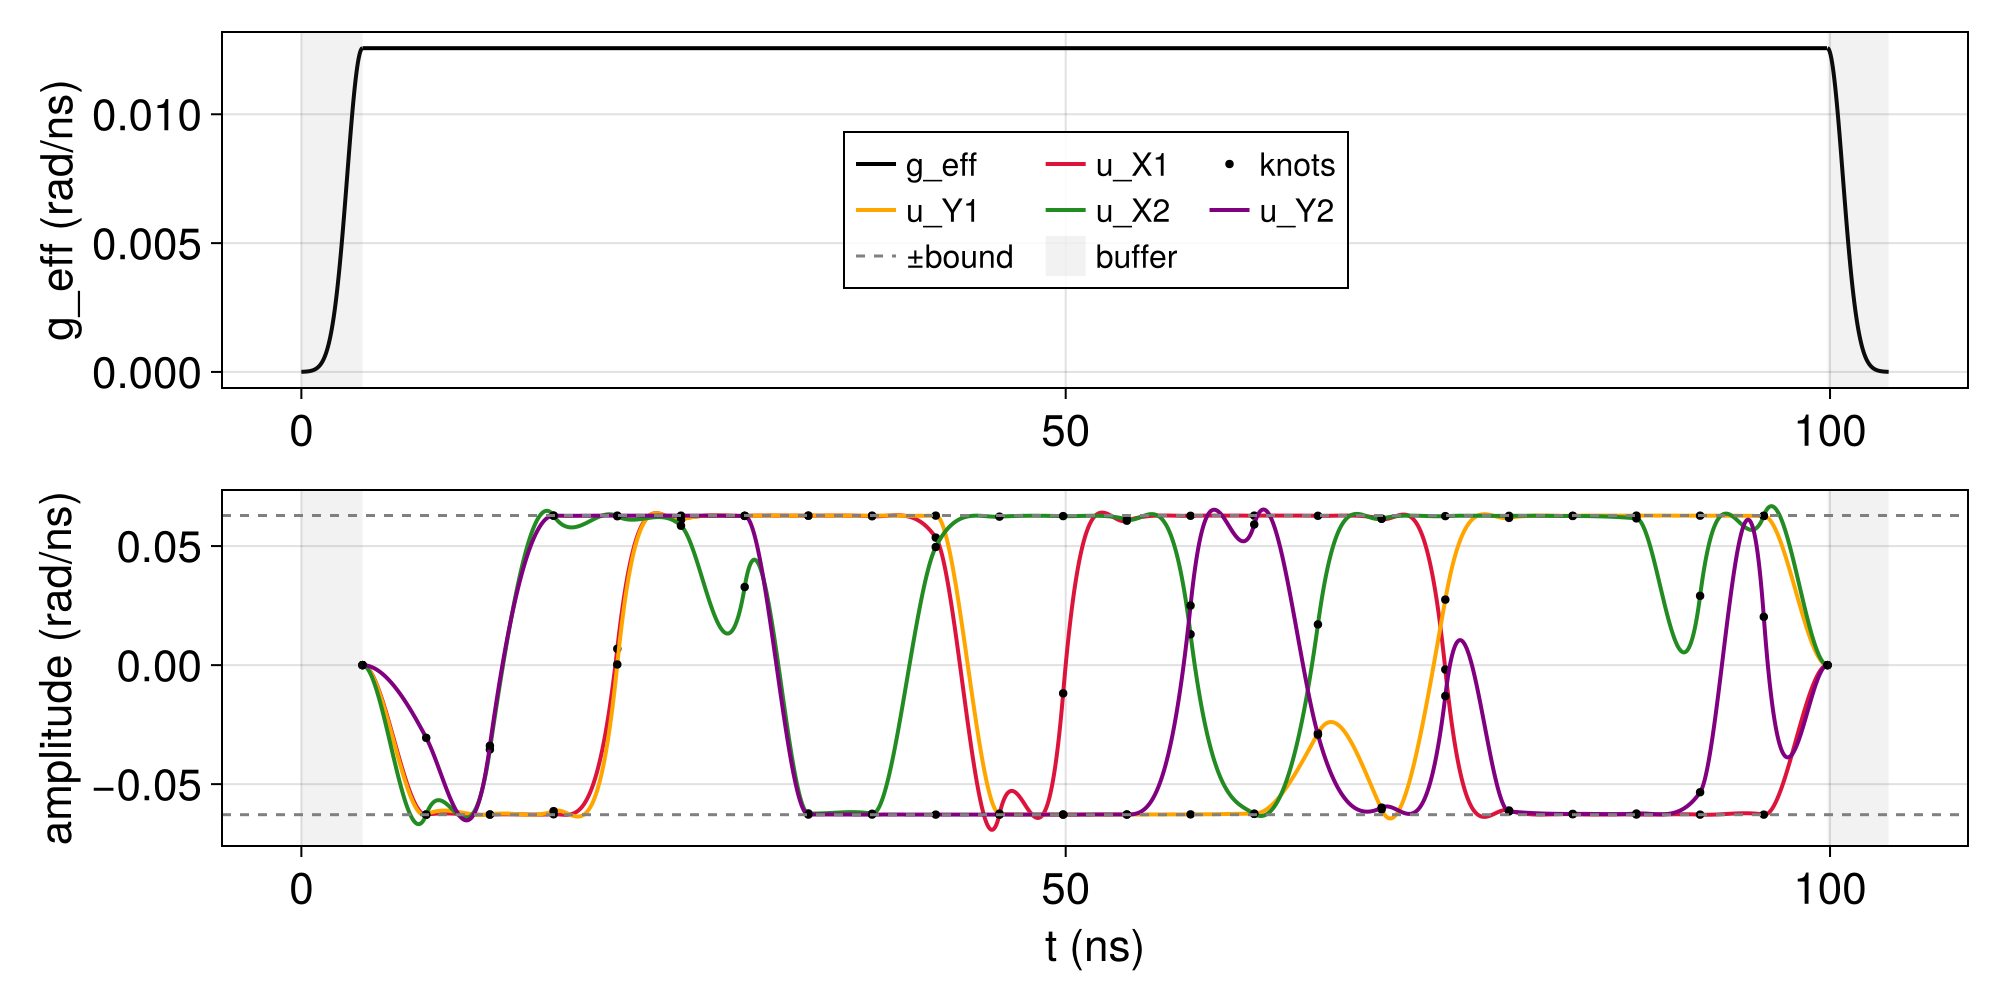

CairoMakie.Screen{IMAGE}


In [ ]:
# Full pulse: Gaussian rise + flat-top (g_eff + microwaves) + Gaussian fall                                                                                                                             
ts_knots, us_knots, ts_fine_mw, us_fine_mw = _spline_fine(traj)                                                                                                                                         
T_flat_opt = ts_fine_mw[end]                                                                                                                                                                            
                                                                                                                                                                                                        
# Build time axis for full pulse                                                                                                                                                                        
dt_plot = 0.05                                                                                                                                                                                          
t_rise_plot = collect(0:dt_plot:buffer_duration)                                                                                                                                                        
t_flat_plot = collect(0:dt_plot:T_flat_opt) .+ buffer_duration                                                                                                                                          
t_fall_plot = collect(0:dt_plot:buffer_duration) .+ buffer_duration .+ T_flat_opt                                                                                                                       
                                                                                                                                                                                                        
# g_eff envelope                                                                                                                                                                                        
g_rise_plot = g_eff .* exp.(-(t_rise_plot .- buffer_duration).^2 ./ (2σ_rise^2))                                                                                                                        
g_flat_plot = fill(g_eff, length(t_flat_plot))                                                                                                                                                          
g_fall_plot = g_eff .* exp.(-(t_fall_plot .- buffer_duration .- T_flat_opt).^2 ./ (2σ_rise^2))                                                                                                          
                                                                                                                                                                                                        
fig = Figure(size=(1000, 500), fontsize=22)                                                                                                                                                             
                                                                                                                                                                                                        
# Top panel: g_eff envelope                                                                                                                                                                             
ax1 = Axis(fig[1, 1], ylabel="g_eff (rad/ns)")
    #title="Full Pulse: Gaussian Square + Optimized Microwaves")                                                                                                                                         
lines!(ax1, t_rise_plot, g_rise_plot; color=:black, linewidth=2)                                                                                                                                        
lines!(ax1, t_flat_plot, g_flat_plot; color=:black, linewidth=2, label="g_eff")                                                                                                                         
lines!(ax1, t_fall_plot, g_fall_plot; color=:black, linewidth=2)                                                                                                                                        
vspan!(ax1, [0], [buffer_duration]; color=(:gray, 0.1))                                                                                                                                                 
vspan!(ax1, [buffer_duration + T_flat_opt], [buffer_duration + T_flat_opt + buffer_duration]; color=(:gray, 0.1))                                                                                       
                                                                                                                                                                                                        
# Bottom panel: microwave controls (shifted to flat-top region)                                                                                                                                         
ax2 = Axis(fig[2, 1], xlabel="t (ns)", ylabel="amplitude (rad/ns)")                                                                                                                                     
labels = ["u_X1", "u_Y1", "u_X2", "u_Y2"]                                                                                                                                                               
colors_ctrl = [:crimson, :orange, :forestgreen, :purple]                                                                                                                                                
                                                                                                                                                                                                        
for (i, (lbl, col)) in enumerate(zip(labels, colors_ctrl))                                                                                                                                              
    lines!(ax2, ts_fine_mw .+ buffer_duration, vec(us_fine_mw[i, :]);                                                                                                                                   
        label=lbl, color=col, linewidth=2)                                                                                                                                                              
    scatter!(ax2, ts_knots .+ buffer_duration, vec(us_knots[i, :]);                                                                                                                                     
        color=:black, markersize=6,                                                                                                                                                                     
        label = i == 1 ? "knots" : nothing)                                                                                                                                                             
end                                                                                                                                                                                                     
hlines!(ax2, [a_bound, -a_bound]; linestyle=:dash, color=:gray, label="±bound")
vspan!(ax2, [0], [buffer_duration]; color=(:gray, 0.1), label="buffer")                                                                                                                                 
vspan!(ax2, [buffer_duration + T_flat_opt], [buffer_duration + T_flat_opt + buffer_duration]; color=(:gray, 0.1))                                                                                       
                                                                                                                                                                                                        
# Combined legend overlaid at the bottom of the top panel                                                                                                                                               
all_plots, all_labels = [], String[]                                                                                                                                                                    
for ax in (ax1, ax2)                                                                                                                                                                                    
    for p in ax.scene.plots                                                                                                                                                                             
        if haskey(p.attributes, :label)
            lbl = p.attributes[:label][]                                                                                                                                                                
            if lbl !== nothing && !isempty(string(lbl))
                push!(all_plots, p)                                                                                                                                                                     
                push!(all_labels, string(lbl))
            end                                                                                                                                                                                         
        end     
    end
end

Legend(fig[1, 1], all_plots, all_labels;                                                                                                                                                                
    halign         = :center,
    valign         = :center,                                                                                                                                                                           
    tellwidth      = false,
    tellheight     = false,
    framevisible   = true,
    backgroundcolor = (:white, 0.85),
    nbanks         = 3,                                                                                                                                                                                 
    labelsize      = 16,
)                                                                                                                                                                                                       
                
linkxaxes!(ax1, ax2) 
save(joinpath(outdir, "figs", "controls.png"), fig)                                                                                                                                                                                   
display(fig)

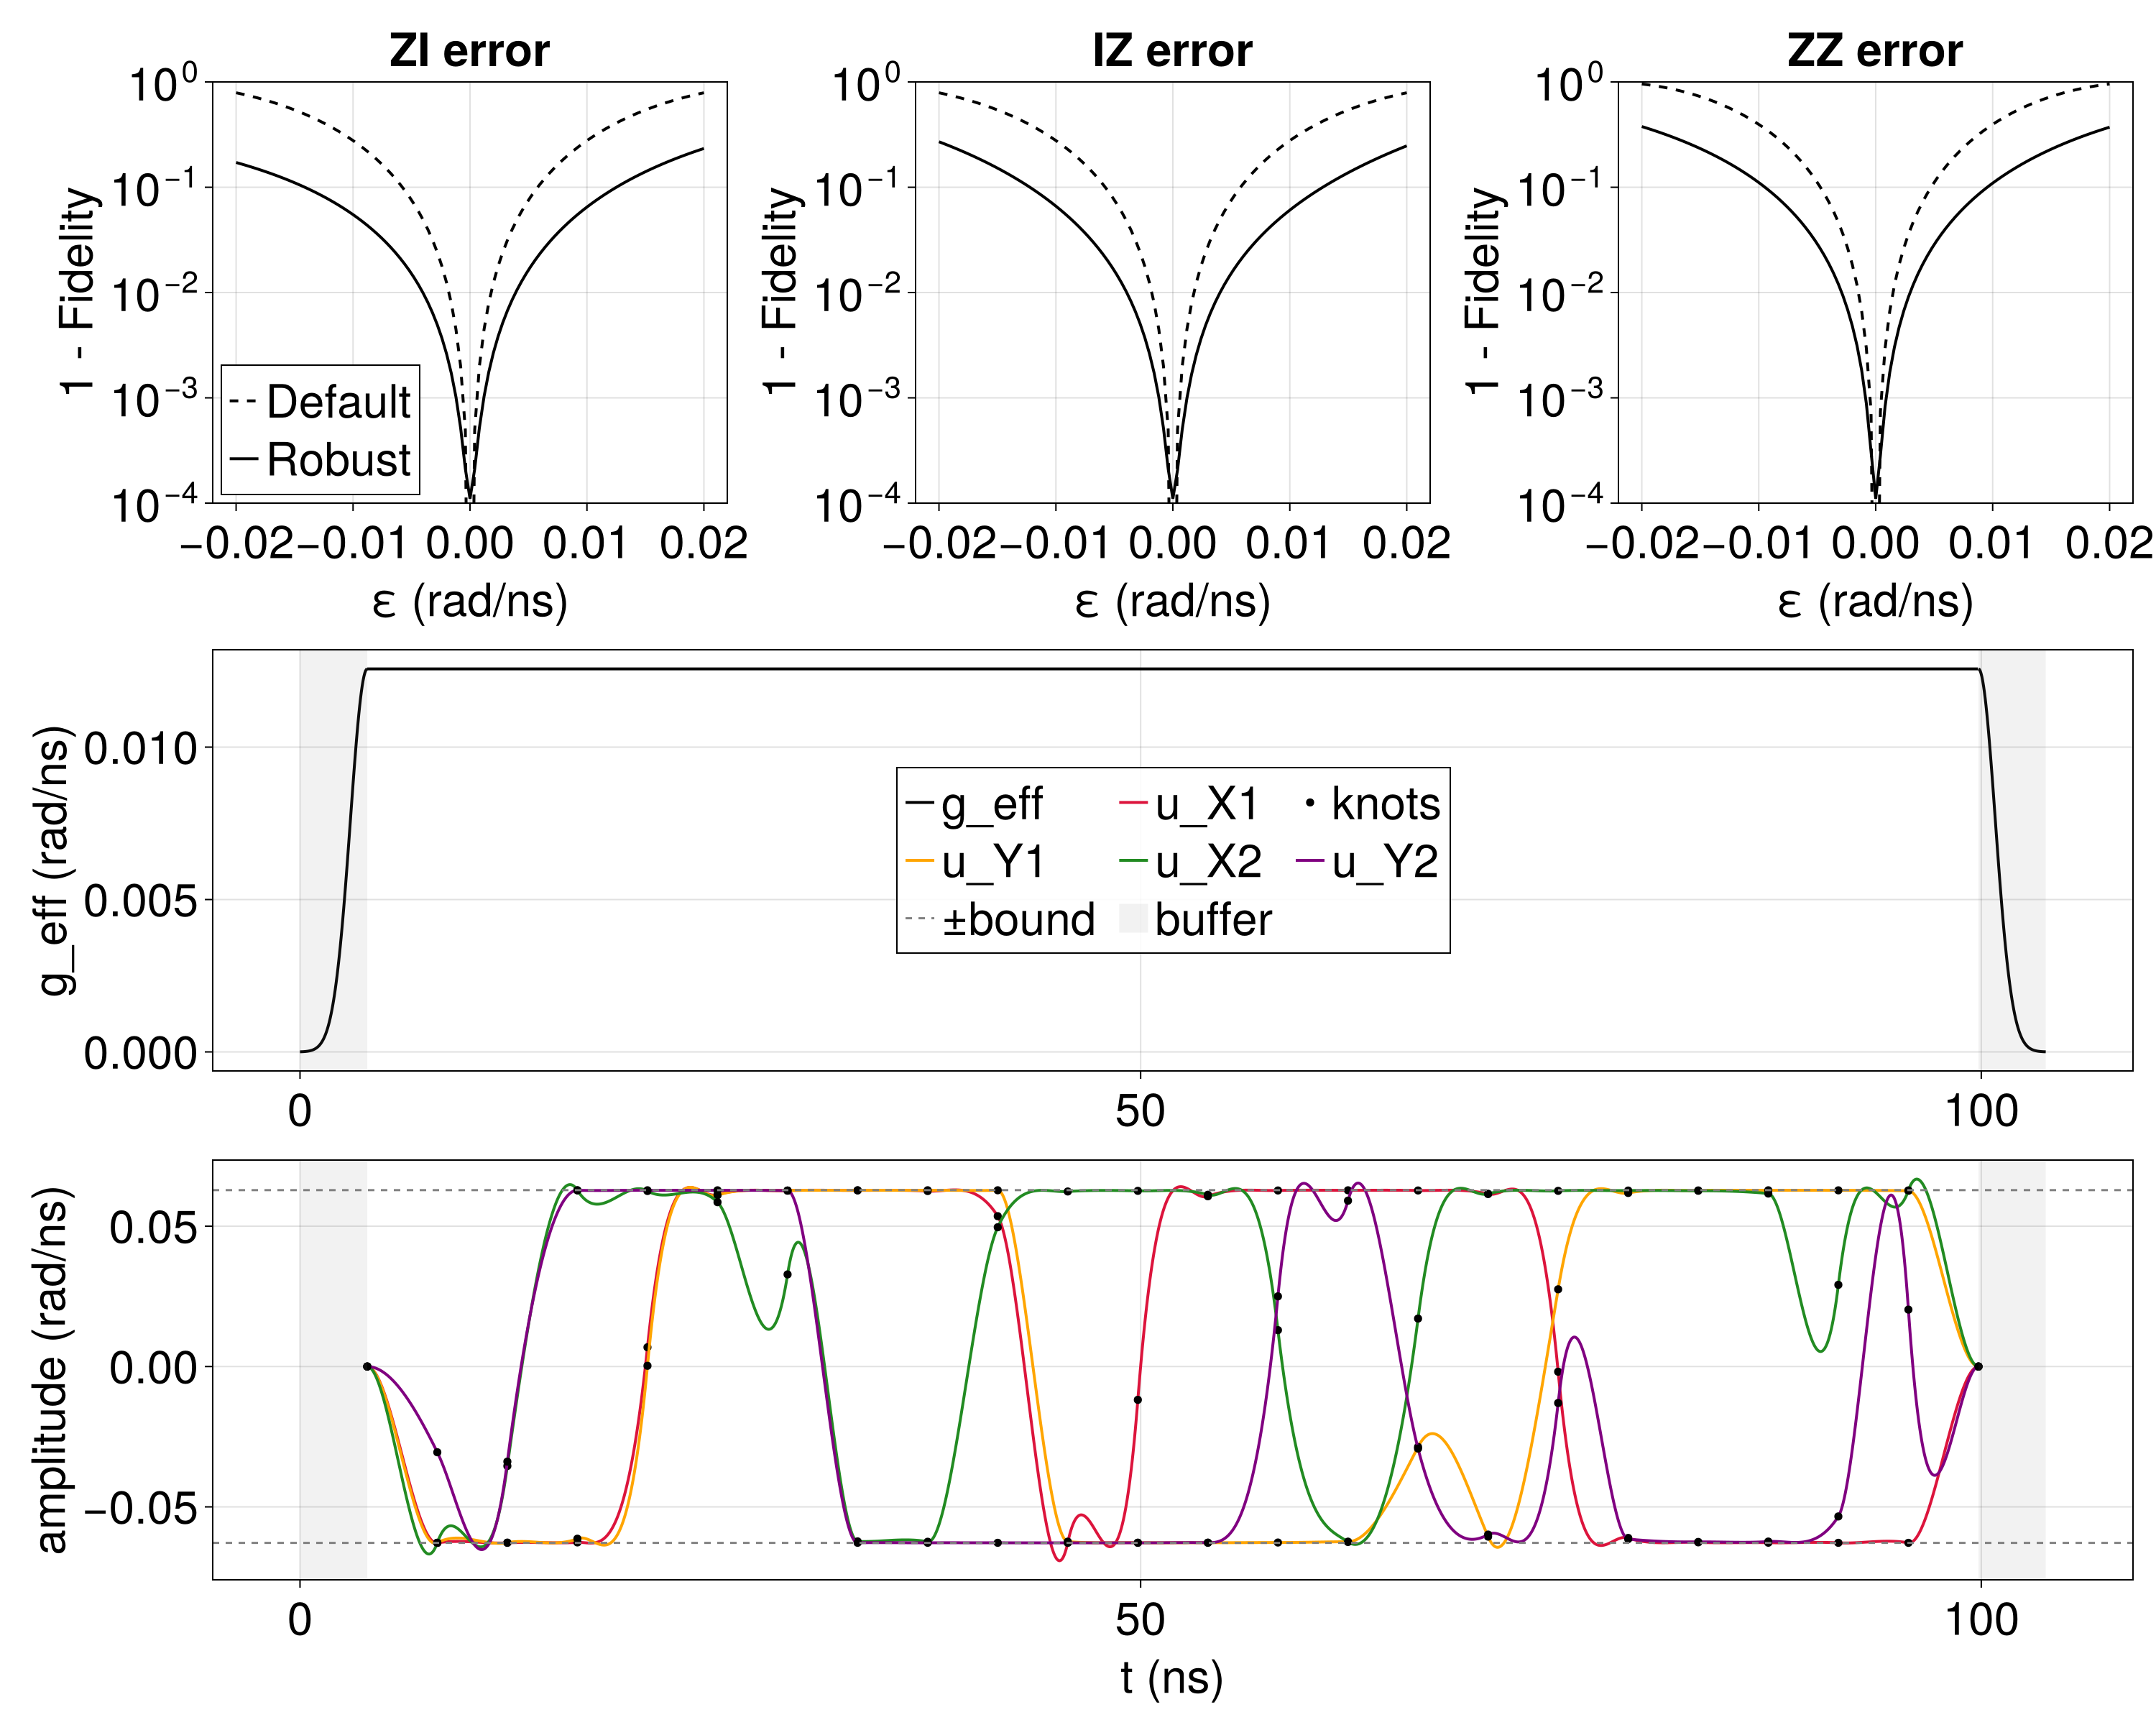

In [55]:
 # Combined: full pulse (top two rows) + infidelity comparison (bottom row)                                                      
 ts_knots, us_knots, ts_fine_mw, us_fine_mw = _spline_fine(traj)                                                                 
 T_flat_opt = ts_fine_mw[end]                                                                                                                                                                            
                                                                                                                                                                                                         
 dt_plot = 0.05                                                                                                                                                                                          
 t_rise_plot = collect(0:dt_plot:buffer_duration)                                                                                                                                                        
 t_flat_plot = collect(0:dt_plot:T_flat_opt) .+ buffer_duration                                                                                                                                          
 t_fall_plot = collect(0:dt_plot:buffer_duration) .+ buffer_duration .+ T_flat_opt                                                                                                                       
                                                                                                                                                                                                         
 g_rise_plot = g_eff .* exp.(-(t_rise_plot .- buffer_duration).^2 ./ (2σ_rise^2))                                                                                                                        
 g_flat_plot = fill(g_eff, length(t_flat_plot))                                                                                                                                                          
 g_fall_plot = g_eff .* exp.(-(t_fall_plot .- buffer_duration .- T_flat_opt).^2 ./ (2σ_rise^2))                                                                                                          
                                                                                                                                                                                                         
 FS = 32
 fig = Figure(size=(1500, 1200), fontsize=FS)                                                                                                                                                            
                                                                                                                                                                                                         
 # --- Row 1: g_eff envelope (spans 3 columns) ---
 ax1 = Axis(fig[2, 1:3], ylabel="g_eff (rad/ns)")                                                                                                                                                        
 lines!(ax1, t_rise_plot, g_rise_plot; color=:black, linewidth=2)                                                                                                                                        
 lines!(ax1, t_flat_plot, g_flat_plot; color=:black, linewidth=2, label="g_eff")
 lines!(ax1, t_fall_plot, g_fall_plot; color=:black, linewidth=2)                                                                                                                                        
 vspan!(ax1, [0], [buffer_duration]; color=(:gray, 0.1))                                                                                                                                                 
 vspan!(ax1, [buffer_duration + T_flat_opt], [buffer_duration + T_flat_opt + buffer_duration]; color=(:gray, 0.1))                                                                                       
                                                                                                                                                                                                         
 # --- Row 2: microwave controls (spans 3 columns) ---                                                                                                                                                   
 ax2 = Axis(fig[3, 1:3], xlabel="t (ns)", ylabel="amplitude (rad/ns)")                                                                                                                                   
 mw_labels = ["u_X1", "u_Y1", "u_X2", "u_Y2"]                                                                                                                                                            
 mw_colors = [:crimson, :orange, :forestgreen, :purple]                                                                                                                                                  
                                                                                                                                                                                                         
 for (i, (lbl, c)) in enumerate(zip(mw_labels, mw_colors))                                                                                                                                               
     lines!(ax2, ts_fine_mw .+ buffer_duration, vec(us_fine_mw[i, :]);                                                                                                                                   
         label=lbl, color=c, linewidth=2)                                                                                                                                                                
     scatter!(ax2, ts_knots .+ buffer_duration, vec(us_knots[i, :]);
         color=:black, markersize=8,                                                                                                                                                                     
         label = i == 1 ? "knots" : nothing)                                                                                                                                                           
 end                                                                                                                                                                                                     
 hlines!(ax2, [a_bound, -a_bound]; linestyle=:dash, color=:gray, label="±bound")                                                                                                                       
 vspan!(ax2, [0], [buffer_duration]; color=(:gray, 0.1), label="buffer")                                                                                                                                 
 vspan!(ax2, [buffer_duration + T_flat_opt], [buffer_duration + T_flat_opt + buffer_duration]; color=(:gray, 0.1))                                                                                       
                                                                                                                                                                                                         
 linkxaxes!(ax1, ax2)                                                                                                                                                                                    
                                                                                                                                                                                                         
 # Combined pulse-plot legend, overlaid at the bottom of the top panel                                                                                                                                   
 all_plots, all_labels = [], String[]
 for ax in (ax1, ax2)                                                                                                                                                                                    
     for p in ax.scene.plots                                                                                                                                                                           
         if haskey(p.attributes, :label)                                                                                                                                                                 
             lbl = p.attributes[:label][]
             if lbl !== nothing && !isempty(string(lbl))                                                                                                                                                 
                 push!(all_plots, p)                                                                                                                                                                     
                 push!(all_labels, string(lbl))
             end                                                                                                                                                                                         
         end                                                                                                                                                                                           
     end
 end

 Legend(fig[2, 1:3], all_plots, all_labels;                                                                                                                                                              
     halign          = :center,
     valign          = :center,                                                                                                                                                                          
     tellwidth       = false,                                                                                                                                                                          
     tellheight      = false,
     framevisible    = true,
     backgroundcolor = (:white, 0.85),
     nbanks          = 3,                                                                                                                                                                                
     labelsize       = FS,
 )                                                                                                                                                                                                       
                                                                                                                                                                                                       
 # --- Row 3: infidelity comparison (one column per error) ---                                                                                                                                           
 for (col, (err_op, err_name)) in enumerate(errors)
     ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="1 - Fidelity",                                                                                                                                  
         title="$err_name error", yscale=log10)                                                                                                                                                          
     lines!(ax, εs, max.(1 .- F_default_vs_eps[err_name], 1e-16);
         color=:black, linewidth=2, linestyle=:dash, label="Default")                                                                                                                                    
     lines!(ax, εs, max.(1 .- F_vs_eps[err_name], 1e-16);                                                                                                                                              
         color=:black, linewidth=2, label="Robust")                                                                                                                                                      
     ylims!(ax, 1e-4, 1.0)                                                                                                                                                                             
     if col == 1                                                                                                                                                                                         
         axislegend(ax, position=:lb, labelsize=FS)                                                                                                                                                    
     end                                                                                                                                                                                                 
 end                                                                                                                                                                                                   

 display(fig)
 save(joinpath(outdir, "figs", "combined.png"), fig)

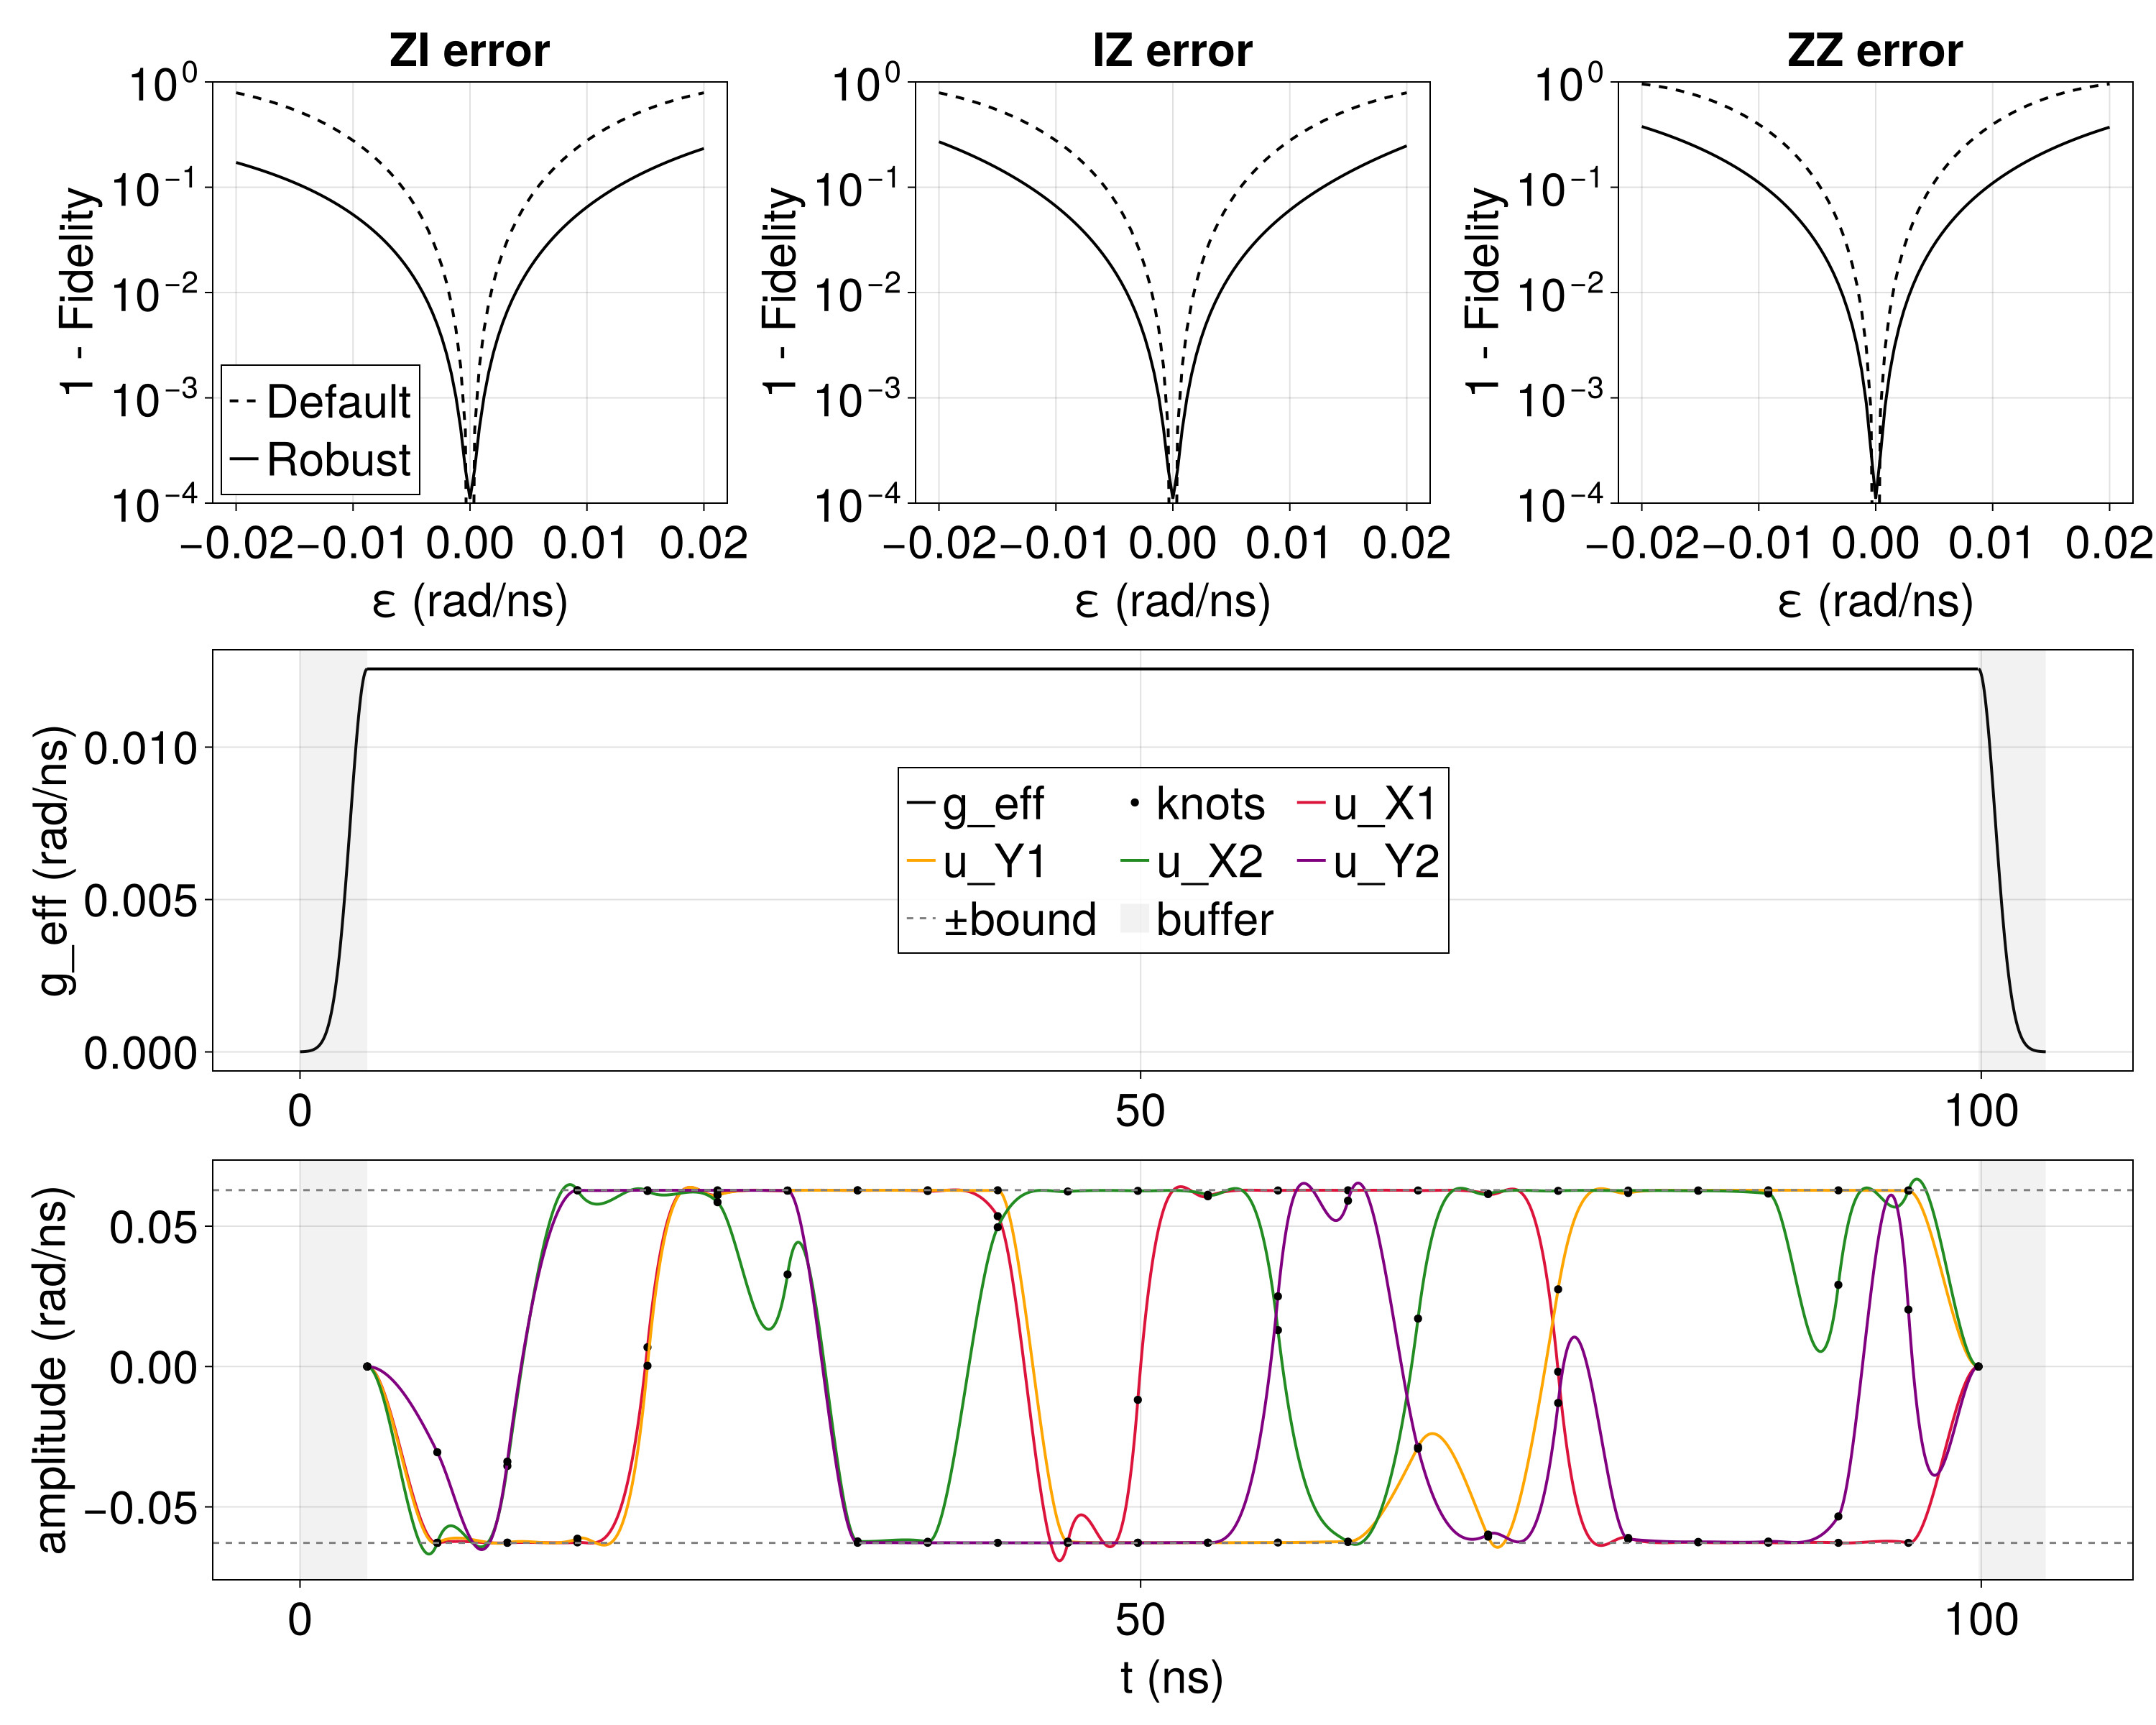

In [57]:
  # Combined: full pulse (top two rows) + infidelity comparison (bottom row)                                                                                                             
  ts_knots, us_knots, ts_fine_mw, us_fine_mw = _spline_fine(traj)                                                                                                                        
  T_flat_opt = ts_fine_mw[end]                                                                                                                                                           
                                                                                                                                                                                         
  dt_plot = 0.05                                                                                                                                                                         
  t_rise_plot = collect(0:dt_plot:buffer_duration)                                                                                                                                     
  t_flat_plot = collect(0:dt_plot:T_flat_opt) .+ buffer_duration                                                                                                                         
  t_fall_plot = collect(0:dt_plot:buffer_duration) .+ buffer_duration .+ T_flat_opt                                                                                                      
                                                                                                                                                                                         
  g_rise_plot = g_eff .* exp.(-(t_rise_plot .- buffer_duration).^2 ./ (2σ_rise^2))                                                                                                       
  g_flat_plot = fill(g_eff, length(t_flat_plot))                                                                                                                                         
  g_fall_plot = g_eff .* exp.(-(t_fall_plot .- buffer_duration .- T_flat_opt).^2 ./ (2σ_rise^2))                                                                                         
                                                                                                                                                                                         
  FS = 32                                                                                                                                                                                
  fig = Figure(size=(1500, 1200), fontsize=FS)                                                                                                                                           
                                                                                                                                                                                         
  # --- Row 2: g_eff envelope (spans 3 columns) ---
  ax1 = Axis(fig[2, 1:3], ylabel="g_eff (rad/ns)")                                                                                                                                       
  lines!(ax1, t_rise_plot, g_rise_plot; color=:black, linewidth=2)                                                                                                                       
  lines!(ax1, t_flat_plot, g_flat_plot; color=:black, linewidth=2, label="g_eff")
  lines!(ax1, t_fall_plot, g_fall_plot; color=:black, linewidth=2)                                                                                                                       
  vspan!(ax1, [0], [buffer_duration]; color=(:gray, 0.1))                                                                                                                                
  vspan!(ax1, [buffer_duration + T_flat_opt], [buffer_duration + T_flat_opt + buffer_duration]; color=(:gray, 0.1))                                                                      
                                                                                                                                                                                         
  # --- Row 3: microwave controls (spans 3 columns) ---                                                                                                                                  
  ax2 = Axis(fig[3, 1:3], xlabel="t (ns)", ylabel="amplitude (rad/ns)")                                                                                                                  
  mw_labels = ["u_X1", "u_Y1", "u_X2", "u_Y2"]                                                                                                                                           
  mw_colors = [:crimson, :orange, :forestgreen, :purple]                                                                                                                                 
  
  for (i, (lbl, c)) in enumerate(zip(mw_labels, mw_colors))                                                                                                                              
      lines!(ax2, ts_fine_mw .+ buffer_duration, vec(us_fine_mw[i, :]);                                                                                                                
          label=lbl, color=c, linewidth=2)                                                                                                                                               
      scatter!(ax2, ts_knots .+ buffer_duration, vec(us_knots[i, :]);                                                                                                                    
          color=:black, markersize=8,
          label = i == 1 ? "knots" : nothing)                                                                                                                                            
  end                                                                                                                                                                                  
  hlines!(ax2, [a_bound, -a_bound]; linestyle=:dash, color=:gray, label="±bound")                                                                                                        
  vspan!(ax2, [0], [buffer_duration]; color=(:gray, 0.1), label="buffer")                                                                                                                
  vspan!(ax2, [buffer_duration + T_flat_opt], [buffer_duration + T_flat_opt + buffer_duration]; color=(:gray, 0.1))
                                                                                                                                                                                         
  linkxaxes!(ax1, ax2)                                                                                                                                                                   
                                                                                                                                                                                         
  # Combined pulse-plot legend                                                                                                                                                           
  all_plots, all_labels = [], String[]                                                                                                                                                 
  for ax in (ax1, ax2)
      for p in ax.scene.plots
          if haskey(p.attributes, :label)
              lbl = p.attributes[:label][]                                                                                                                                               
              if lbl !== nothing && !isempty(string(lbl))
                  push!(all_plots, p)                                                                                                                                                    
                  push!(all_labels, string(lbl))                                                                                                                                       
              end                                                                                                                                                                        
          end
      end                                                                                                                                                                                
  end                                                                                                                                                                                  

  # Reorder: g_eff first, knots second, then the rest
  desired_first = ["g_eff", "knots"]
  ordered_plots, ordered_labels = [], String[]                                                                                                                                           
  for lbl in desired_first
      idx = findfirst(==(lbl), all_labels)                                                                                                                                               
      if idx !== nothing                                                                                                                                                               
          push!(ordered_plots, all_plots[idx])                                                                                                                                           
          push!(ordered_labels, all_labels[idx])
      end                                                                                                                                                                                
  end                                                                                                                                                                                  
  for (p, lbl) in zip(all_plots, all_labels)
      if !(lbl in desired_first)                                                                                                                                                         
          push!(ordered_plots, p)
          push!(ordered_labels, lbl)                                                                                                                                                     
      end                                                                                                                                                                              
  end

  Legend(fig[2, 1:3], ordered_plots, ordered_labels;                                                                                                                                     
      halign          = :center,
      valign          = :center,                                                                                                                                                         
      tellwidth       = false,                                                                                                                                                         
      tellheight      = false,
      framevisible    = true,                                                                                                                                                            
      backgroundcolor = (:white, 0.85),
      nbanks          = 3,                                                                                                                                                               
      labelsize       = FS,                                                                                                                                                            
  )

  # --- Row 1: infidelity comparison (one column per error) ---                                                                                                                          
  for (col, (err_op, err_name)) in enumerate(errors)
      ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="1 - Fidelity",                                                                                                                 
          title="$err_name error", yscale=log10)                                                                                                                                         
      lines!(ax, εs, max.(1 .- F_default_vs_eps[err_name], 1e-16);
          color=:black, linewidth=2, linestyle=:dash, label="Default")                                                                                                                   
      lines!(ax, εs, max.(1 .- F_vs_eps[err_name], 1e-16);                                                                                                                             
          color=:black, linewidth=2, label="Robust")                                                                                                                                     
      ylims!(ax, 1e-4, 1.0)                                                                                                                                                            
      if col == 1                                                                                                                                                                        
          axislegend(ax, position=:lb, labelsize=FS)                                                                                                                                     
      end
  end                                                                                                                                                                                    
                                                                                                                                                                                       
  display(fig)
  save(joinpath(outdir, "figs", "combined.png"), fig)